In [97]:
import numpy as np

def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

# OOD Results

In [7]:
import json
import os
import numpy as np
from scipy import stats

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        
        # Explicitly handle None (JSON null)
        if val is None:
            return -np.inf
        
        # Attempt to convert to float (handles strings like "10.5")
        return float(val)
        
    except (KeyError, TypeError, ValueError):
        # KeyError: Key missing
        # TypeError: Trying to access [key] on a None object
        # ValueError: Found a string that isn't a number
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("ood_results", [])
    if not results:
        return None
    
    # 1. Extract raw scores for every method for every policy
    scores = {m: [] for m in METRIC_PATHS.keys()}
    
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    # Convert to numpy arrays for easier handling
    for m in scores:
        scores[m] = np.array(scores[m])

    # 2. Determine True Best Value (Oracle)
    # Validate that we have at least one valid ground truth value
    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    # 3. Calculate Rankings and Regrets
    file_output = {
        "rankings": {},
        "regrets": {}
    }

    for method, values in scores.items():
        # If a method has all -inf (all null), argsort is arbitrary but won't crash.
        # [::-1] reverses it to descending (Best to Worst).
        ranking = np.argsort(values)[::-1]
        
        file_output["rankings"][method] = ranking.tolist()
        
        if method != "env_mc":
            # Identify which policy this method thinks is best
            selected_policy_idx = ranking[0]
            
            # If the method picked a policy that has a NULL env_mc (unlikely but possible),
            # treating it as a standard float calculation might fail if we didn't sanitize inputs.
            # But true_values is sanitized to -inf if missing.
            val_of_selected = true_values[selected_policy_idx]
            
            # Sanity check: If the true value of the selected policy is -inf (missing data),
            # the regret is infinite/undefined.
            if np.isinf(val_of_selected):
                # Regret is theoretically infinite if we picked a policy with no result
                # Here we default to a very large number or just 0.0 depending on preference.
                # Usually, we skip, but for stability, let's record nan.
                regret = np.nan 
            else:
                regret = true_optimal_val - val_of_selected
            
            file_output["regrets"][method] = float(regret)

    return file_output

def aggregate_results(seed_range, file_pattern="./ood/hopper_pipeline/resnet/summary_{}.json"):
    """""
    Iterates over seeds, processes files, and aggregates results into lists.
    """
    
    # Data structures to hold aggregated lists
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    
    valid_seeds = []

    print(f"Processing seeds {seed_range}...")

    for seed in seed_range:
        filename = file_pattern.format(seed)
        
        if not os.path.exists(filename):
            # print(f"Warning: File {filename} not found. Skipping.")
            continue
            
        # Process the individual file
        single_res = process_single_seed(filename)
        
        # If processing failed (e.g. env_mc was null), skip aggregation for this seed
        if single_res is None:
            continue

        valid_seeds.append(seed)
        
        # Append to aggregates
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
            
        for method in agg_regrets.keys():
            val = single_res["regrets"][method]
            # Only append if it's not NaN, or decide how you want to handle NaN regrets
            # Here we append it, and np.nanmean can handle it later if needed
            agg_regrets[method].append(val)

    return agg_rankings, agg_regrets, valid_seeds

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Define the range of seeds you want to process
    
    SEEDS = list(range(0, 10))
    
    # Run aggregation
    rankings, regrets, processed_seeds = aggregate_results(SEEDS)

    if not processed_seeds:
        print("No valid files processed.")
    else:
        print("\n" + "="*30)
        print(f"AGGREGATED RESULTS ({len(processed_seeds)} seeds)")
        print("="*30)

        # 1. Output True Rankings
        print("\n--- True Rankings (env_mc) [List of Lists] ---")
        # Print first 3 to avoid clutter if list is huge
        print(str(rankings['env_mc'][:3]) + " ... (showing first 3)")

        # 2. Output OPE Rankings
        print("\n--- OPE Rankings [List of Lists] ---")
        for method in ['supervised', 'kendall']:
            print(f"\nMethod: {method}")
            print(str(rankings[method][:3]) + " ...")

        # 3. Output OPE Regrets
        print("\n--- OPE Regrets [List of Floats] ---")
        for method in ['supervised', 'kendall']:
            # Use nanmean to safely calculate mean ignoring NaNs
            avg_regret = np.nanmean(regrets[method])
            
            # Count how many valid regrets we actually have
            valid_count = np.count_nonzero(~np.isnan(regrets[method]))
            
            print(f"\nMethod: {method}")
            # print(f"Values: {regrets[method]}")
            print(f"Average Regret: {avg_regret:.4f} (calculated over {valid_count} valid seeds)")

Processing seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...

AGGREGATED RESULTS (9 seeds)

--- True Rankings (env_mc) [List of Lists] ---
[[4, 1, 3, 0, 2], [1, 4, 3, 0, 2], [1, 4, 3, 0, 2]] ... (showing first 3)

--- OPE Rankings [List of Lists] ---

Method: supervised
[[1, 4, 3, 0, 2], [4, 1, 0, 3, 2], [4, 1, 0, 3, 2]] ...

Method: kendall
[[1, 4, 3, 0, 2], [1, 4, 3, 0, 2], [4, 1, 3, 0, 2]] ...

--- OPE Regrets [List of Floats] ---

Method: supervised
Average Regret: 1.8296 (calculated over 9 valid seeds)

Method: kendall
Average Regret: 0.6085 (calculated over 9 valid seeds)


In [3]:
def analyze_performance(rankings, regrets):
    """
    Calculates Average Regret (+- SE), Spearman's Correlation (+- SE),
    and Pass@1 (+- SE).
    
    Args:
        rankings (dict): Dictionary of lists of lists.
        regrets (dict): Dictionary of lists of floats.
    """
    
    # Helper to calculate Mean and Standard Error
    def get_stats(data):
        if not data:
            return 0.0, 0.0
        data = np.array(data)
        mean = np.mean(data)
        # ddof=1 for sample standard deviation
        se = np.std(data, ddof=1) / np.sqrt(len(data)) 
        return mean, se

    # Helper to convert "sorted indices" into a "rank vector"
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    # Adjusted column widths for the new metric
    print(f"{'METHOD':<15} | {'AVG REGRET':<18} | {'AVG SPEARMAN':<18} | {'PASS@1 (%)':<18}")
    print("-" * 75)

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    
    for method in methods:
        method_rankings = rankings[method]
        
        # 1. Regret Statistics
        method_regrets = regrets[method]
        reg_mean, reg_se = get_stats(method_regrets)
        
        # 2. Spearman & Pass@1 Statistics
        spearman_scores = []
        pass1_scores = []
        
        for true_sort, method_sort in zip(true_rankings, method_rankings):
            # --- Spearman Calculation ---
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            
            # --- Pass@1 Calculation ---
            # Compare the first element (index 0) of both sorted lists
            # 1.0 if they identify the same best policy, 0.0 otherwise
            is_match = 1.0 if true_sort[0] == method_sort[0] else 0.0
            pass1_scores.append(is_match)
        corr_mean, corr_se = get_stats(spearman_scores)
        p1_mean, p1_se = get_stats(pass1_scores)
        
        # Convert Pass@1 to percentage
        p1_mean_pct = p1_mean * 100
        p1_se_pct = p1_se * 100
        
        # 3. Print Row
        reg_str = f"{reg_mean:.2f} ± {reg_se:.2f}"
        corr_str = f"{corr_mean:.3f} ± {corr_se:.3f}"
        p1_str = f"{p1_mean_pct:.1f}% ± {p1_se_pct:.1f}%"
        
        print(f"{method:<15} | {reg_str:<18} | {corr_str:<18} | {p1_str:<18}")

# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Assuming 'rankings' and 'regrets' are already computed 
    # via the aggregate_results function from the previous script
    
    print("\n" + "="*30)
    print("STATISTICAL ANALYSIS")
    print("="*30)
    
    analyze_performance(rankings, regrets)


STATISTICAL ANALYSIS
METHOD          | AVG REGRET         | AVG SPEARMAN       | PASS@1 (%)        
---------------------------------------------------------------------------
supervised      | 1.83 ± 0.91        | 0.811 ± 0.042      | 11.1% ± 11.1%     
kendall         | 0.61 ± 0.60        | 0.911 ± 0.042      | 55.6% ± 17.6%     


# Results processing script

In [95]:
import json
import os
import numpy as np
from scipy import stats

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"],
    "vaml": ["dynamics", "value_aware"],
    "morel" : ["dynamics", "morel_pessimistic"],
    "mopo" : ["dynamics", "mopo_penalized"],
    "romi" : ["dynamics", "romi_model_return"],
    "omd" : ["dynamics", "omd"]
}

# Top-k setting used for Top-k Regret.
TOP_K = 3

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        
        # Explicitly handle None (JSON null)
        if val is None:
            return -np.inf
        
        # Attempt to convert to float (handles strings like "10.5")
        return float(val)
        
    except (KeyError, TypeError, ValueError):
        # KeyError: Key missing
        # TypeError: Trying to access [key] on a None object
        # ValueError: Found a string that isn't a number
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings, regrets, and top-k regrets."""
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    # 1. Extract raw scores for every method for every policy
    scores = {m: [] for m in METRIC_PATHS.keys()}
    
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    # Convert to numpy arrays for easier handling
    for m in scores:
        scores[m] = np.array(scores[m])

    # 2. Determine True Best Value (Oracle)
    # Validate that we have at least one valid ground truth value
    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    # 3. Calculate Rankings, Regrets, and Top-k Regrets
    file_output = {
        "rankings": {},
        "regrets": {},
        "topk_regrets": {}
    }

    for method, values in scores.items():
        # If a method has all -inf (all null), argsort is arbitrary but won't crash.
        # [::-1] reverses it to descending (Best to Worst).
        ranking = np.argsort(values)[::-1]
        
        file_output["rankings"][method] = ranking.tolist()
        
        if method != "env_mc":
            # Top-1 regret (existing metric)
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            if np.isinf(val_of_selected):
                regret = np.nan
            else:
                regret = true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)

            # Top-k regret: best true value among method's top-k predictions
            k_eff = min(TOP_K, len(ranking))
            topk_policy_indices = ranking[:k_eff]
            topk_true_values = true_values[topk_policy_indices]
            finite_topk_true_values = topk_true_values[~np.isinf(topk_true_values)]

            if finite_topk_true_values.size == 0:
                topk_regret = np.nan
            else:
                topk_best_true_val = np.max(finite_topk_true_values)
                topk_regret = true_optimal_val - topk_best_true_val

            file_output["topk_regrets"][method] = float(topk_regret)

    return file_output

def aggregate_results(seed_range, file_pattern="./test/ant_pipeline/mlp/summary_VAML_{}.json"):
    """""
    Iterates over seeds, processes files, and aggregates results into lists.
    """
    
    # Data structures to hold aggregated lists
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    agg_topk_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    
    valid_seeds = []

    print(f"Processing seeds {seed_range}...")

    for seed in seed_range:
        filename = file_pattern.format(seed)
        
        if not os.path.exists(filename):
            # print(f"Warning: File {filename} not found. Skipping.")
            continue
            
        # Process the individual file
        single_res = process_single_seed(filename)
        
        # If processing failed (e.g. env_mc was null), skip aggregation for this seed
        if single_res is None:
            continue

        valid_seeds.append(seed)
        
        # Append to aggregates
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
            
        for method in agg_regrets.keys():
            val = single_res["regrets"][method]
            topk_val = single_res["topk_regrets"][method]
            # Only append if it's not NaN, or decide how you want to handle NaN regrets
            # Here we append it, and np.nanmean can handle it later if needed
            agg_regrets[method].append(val)
            agg_topk_regrets[method].append(topk_val)

    return agg_rankings, agg_regrets, agg_topk_regrets, valid_seeds


if __name__ == "__main__":

    SEEDS = list(range(0,10))
    
    rankings, regrets, topk_regrets, processed_seeds = aggregate_results(SEEDS)

    if not processed_seeds:
        print("No valid files processed.")
    else:
        print("\n" + "="*30)
        print(f"AGGREGATED RESULTS ({len(processed_seeds)} seeds)")
        print("="*30)

        # 1. Output True Rankings
        print("\n--- True Rankings (env_mc) [List of Lists] ---")
        # Print first 3 to avoid clutter if list is huge
        print(str(rankings['env_mc'][:3]) + " ... (showing first 3)")

        # 2. Output OPE Rankings
        print("\n--- OPE Rankings [List of Lists] ---")
        for method in ['supervised', 'q_estimate', 'kendall', 'hinge', 'listnet', 'vaml', 'morel', 'mopo', 'romi']:
            print(f"\nMethod: {method}")
            print(str(rankings[method][:3]) + " ...")

        # 3. Output OPE Regrets
        print("\n--- OPE Regrets [List of Floats] ---")
        for method in ['supervised', 'q_estimate', 'kendall', 'hinge', 'listnet', 'vaml', 'morel', 'mopo', 'romi']:
            avg_regret = np.nanmean(regrets[method])
            avg_topk_regret = np.nanmean(topk_regrets[method])
            
            # Count how many valid regrets we actually have
            valid_count = np.count_nonzero(~np.isnan(regrets[method]))
            valid_topk_count = np.count_nonzero(~np.isnan(topk_regrets[method]))
            
            print(f"\nMethod: {method}")
            print(f"Average Regret: {avg_regret:.4f} (calculated over {valid_count} valid seeds)")
            print(f"Average Top-{TOP_K} Regret: {avg_topk_regret:.4f} (calculated over {valid_topk_count} valid seeds)")

Processing seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...

AGGREGATED RESULTS (10 seeds)

--- True Rankings (env_mc) [List of Lists] ---
[[5, 4, 3, 1, 2, 0], [5, 4, 3, 1, 2, 0], [5, 4, 3, 1, 2, 0]] ... (showing first 3)

--- OPE Rankings [List of Lists] ---

Method: supervised
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: q_estimate
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: kendall
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: hinge
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: listnet
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: vaml
[[0, 4, 3, 1, 2, 5], [0, 1, 2, 3, 4, 5], [2, 1, 3, 4, 5, 0]] ...

Method: morel
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: mopo
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: romi
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

--- OPE Regrets [

In [96]:
def analyze_performance(rankings, regrets, topk_regrets=None, top_k=3):
    """
    Calculates Average Regret (+- SE), Top-k Regret (+- SE),
    Spearman's Correlation (+- SE), and Pass@1 (+- SE).
    
    Args:
        rankings (dict): Dictionary of lists of lists.
        regrets (dict): Dictionary of lists of floats.
        topk_regrets (dict, optional): Dictionary of lists of top-k regrets.
        top_k (int): k used for top-k regret.
    """
    
    def get_stats(data):
        if not data:
            return 0.0, 0.0
        data = np.array(data)
        mean = np.nanmean(data)
        finite_count = np.count_nonzero(~np.isnan(data))
        if finite_count <= 1:
            return mean, 0.0
        # ddof=1 for sample standard deviation
        se = np.nanstd(data, ddof=1) / np.sqrt(finite_count)
        return mean, se

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    print(f"{'METHOD':<15} | {'AVG REGRET':<18} | {f'TOP-{top_k} REGRET':<18} | {'AVG SPEARMAN':<18} | {'PASS@1 (%)':<18}")
    print("-" * 100)

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    
    for method in methods:
        method_rankings = rankings[method]
        
        method_regrets = regrets[method]
        reg_mean, reg_se = get_stats(method_regrets)

        if topk_regrets is not None and method in topk_regrets:
            method_topk_regrets = topk_regrets[method]
        else:
            method_topk_regrets = method_regrets
        topk_mean, topk_se = get_stats(method_topk_regrets)
        
        spearman_scores = []
        pass1_scores = []
        
        for true_sort, method_sort in zip(true_rankings, method_rankings):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            

            is_match = 1.0 if true_sort[0] == method_sort[0] else 0.0
            pass1_scores.append(is_match)
        corr_mean, corr_se = get_stats(spearman_scores)
        p1_mean, p1_se = get_stats(pass1_scores)
        
        p1_mean_pct = p1_mean * 100
        p1_se_pct = p1_se * 100
        
        reg_str = f"{reg_mean:.2f} +/- {reg_se:.2f}"
        topk_str = f"{topk_mean:.2f} +/- {topk_se:.2f}"
        corr_str = f"{corr_mean:.3f} +/- {corr_se:.3f}"
        p1_str = f"{p1_mean_pct:.1f}% +/- {p1_se_pct:.1f}%"
        
        print(f"{method:<15} | {reg_str:<18} | {topk_str:<18} | {corr_str:<18} | {p1_str:<18}")

if __name__ == "__main__":
    
    print("\n" + "="*30)
    print("STATISTICAL ANALYSIS")
    print("="*30)
    
    analyze_performance(rankings, regrets, topk_regrets=topk_regrets, top_k=TOP_K)


STATISTICAL ANALYSIS
METHOD          | AVG REGRET         | TOP-3 REGRET       | AVG SPEARMAN       | PASS@1 (%)        
----------------------------------------------------------------------------------------------------
q_estimate      | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015    | 100.0% +/- 0.0%   
supervised      | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015    | 100.0% +/- 0.0%   
kendall         | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015    | 100.0% +/- 0.0%   
hinge           | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015    | 100.0% +/- 0.0%   
listnet         | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015    | 100.0% +/- 0.0%   
vaml            | 12.50 +/- 0.89     | 3.74 +/- 0.98      | -0.377 +/- 0.114   | 0.0% +/- 0.0%     
morel           | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015    | 100.0% +/- 0.0%   
mopo            | 0.00 +/- 0.00      | 0.00 +/- 0.00      | 0.920 +/- 0.015  

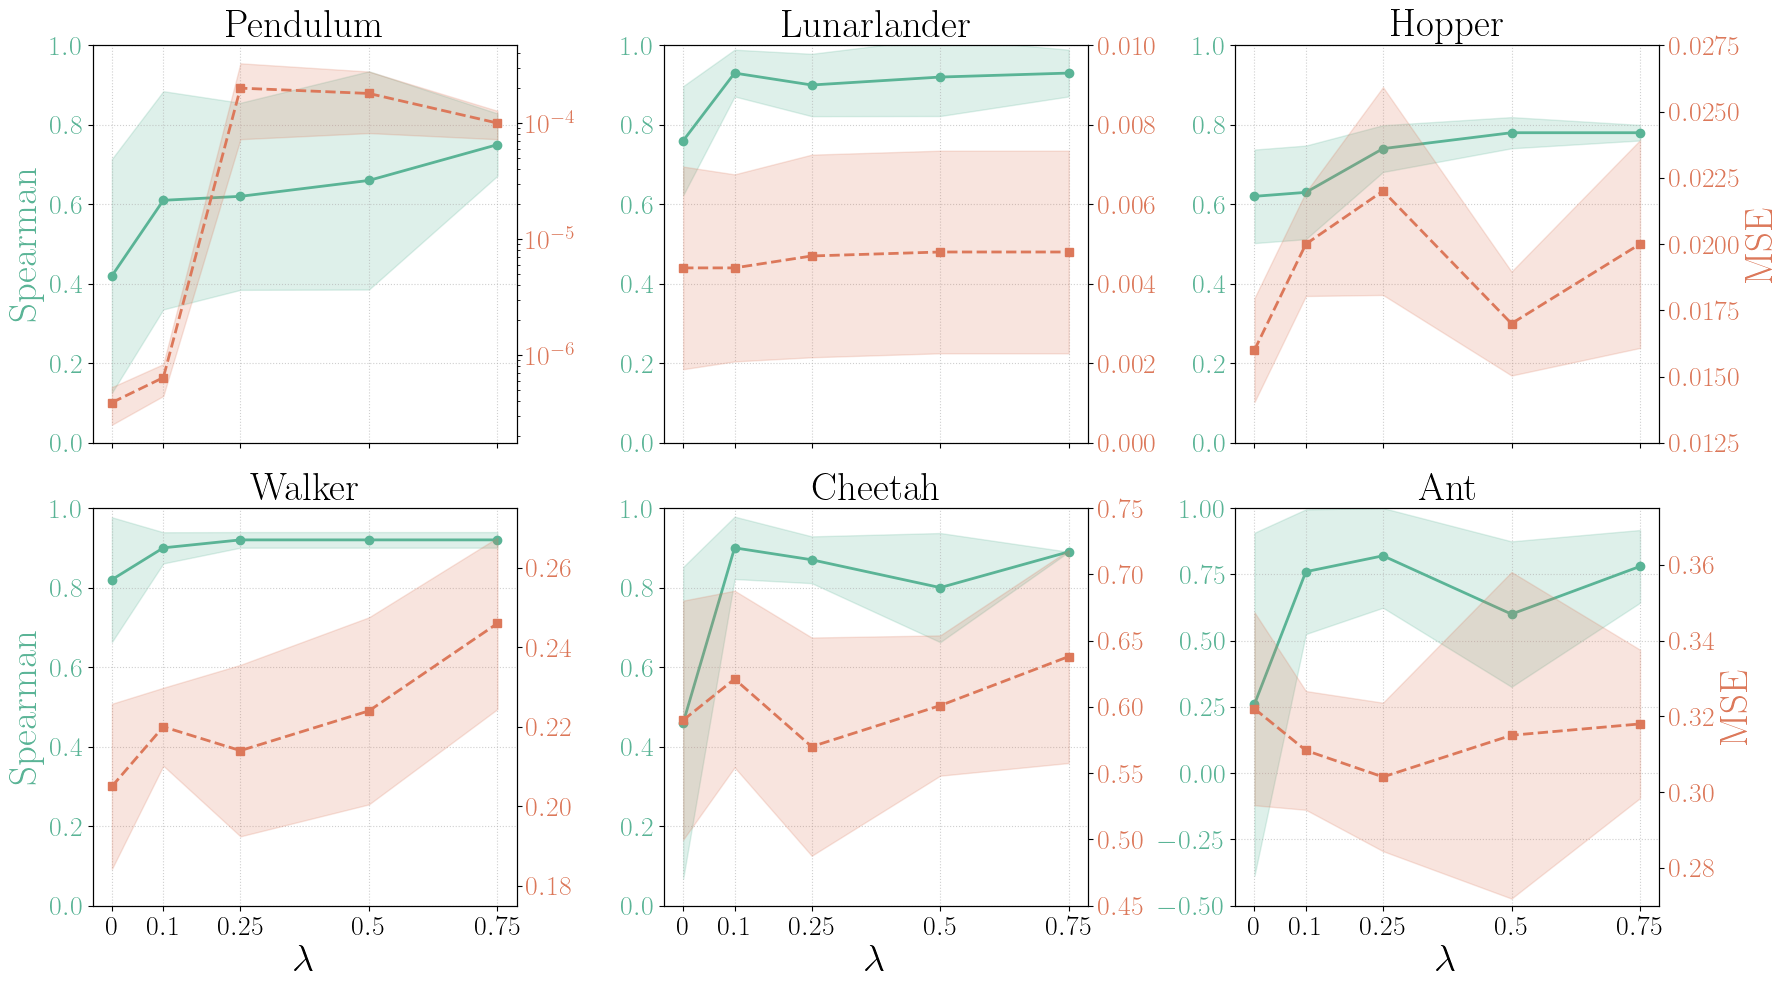

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('text', usetex=True)
rc('font', family='serif')

environments = {
    'Pendulum': {
        'lambdas': [0, 0.1, 0.25, 0.5, 0.75],
        'spearman': [0.42, 0.61, 0.62, 0.66, 0.75],
        'spearman_ses': [0.15, 0.14, 0.12, 0.14, 0.04],
        'mse': [3.9e-7, 6.4e-7, 2.0e-4, 1.8e-4, 1.0e-4],
        'mse_ses': [7.1e-8, 1.0e-7, 6.5e-5, 5.0e-5, 1.4e-5],
        'mse_log': True,
        'mse_ylim': None
    },
    'Lunarlander': {
        'lambdas': [0, 0.1, 0.25, 0.5, 0.75],
        'spearman': [0.76, 0.93, 0.90, 0.92, 0.93],
        'spearman_ses': [0.07, 0.03, 0.04, 0.05, 0.03],
        'mse': [0.0044, 0.0044, 0.0047, 0.0048, 0.0048],
        'mse_ses': [0.0013, 0.0012, 0.0013, 0.0013, 0.0013],
        'mse_log': False,
        'mse_ylim': (0, 0.01)
    },
    'Hopper': {
        'lambdas': [0, 0.1, 0.25, 0.5, 0.75],
        'spearman': [0.62, 0.63, 0.74, 0.78, 0.78],
        'spearman_ses': [0.06, 0.06, 0.03, 0.02, 0.01],
        'mse': [0.016, 0.020, 0.022, 0.017, 0.020],
        'mse_ses': [0.001, 0.001, 0.002, 0.001, 0.002],
        'mse_log': False,
        'mse_ylim': (0.0125, 0.0275)
    },
    'Walker': {
        'lambdas': [0, 0.1, 0.25, 0.5, 0.75],
        'spearman': [0.82, 0.90, 0.92, 0.92, 0.92],
        'spearman_ses': [0.08, 0.02, 0.01, 0.01, 0.01],
        'mse': [0.205, 0.220, 0.214, 0.224, 0.246],
        'mse_ses': [0.0106, 0.005, 0.011, 0.012, 0.011],
        'mse_log': False,
        'mse_ylim': (0.175, 0.275)
    },
    'Cheetah': {
        'lambdas': [0, 0.1, 0.25, 0.5, 0.75],
        'spearman': [0.46, 0.90, 0.87, 0.80, 0.89],
        'spearman_ses': [0.2, 0.04, 0.03, 0.07, 0.00],
        'mse': [0.590, 0.621, 0.570, 0.601, 0.638],
        'mse_ses': [0.046, 0.034, 0.042, 0.027, 0.041],
        'mse_log': False,
        'mse_ylim': (0.45, 0.75)
    },
    'Ant': {
        'lambdas': [0, 0.1, 0.25, 0.5, 0.75],
        'spearman': [0.26, 0.76, 0.82, 0.6, 0.78],
        'spearman_ses': [0.33, 0.12, 0.10, 0.14, 0.07],
        'mse': [0.322, 0.311, 0.304, 0.315, 0.318],
        'mse_ses': [0.013, 0.008, 0.010, 0.022, 0.010],
        'mse_log': False,
        'mse_ylim': (0.27, 0.375),
        'spearman_ylim': (-0.5, 1)
    }
}

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

color_spearman = (90/255, 180/255, 150/255)
color_mse = (220/255, 120/255, 90/255)

for idx, (env_name, data) in enumerate(environments.items()):
    ax1 = axes[idx]
    
    # Determine column position (0, 1, or 2) and row position
    col = idx % 3
    row = idx // 3
    
    # Plot Spearman
    # Only show x-label on bottom row
    if row == 1:
        ax1.set_xlabel(r'$\lambda$', fontsize=28)
    # Only show Spearman label on leftmost column
    if col == 0:
        ax1.set_ylabel(r'Spearman', color=color_spearman, fontsize=28)
    ax1.plot(data['lambdas'], data['spearman'], color=color_spearman, marker='o', 
             linestyle='-', linewidth=2, label='Spearman')
    
    # Handle special case for Ant environment
    if 'spearman_ylim' in data:
        upper_bound = np.minimum(np.array(data['spearman']) + 1.96 * np.array(data['spearman_ses']), 1.0)
        ax1.fill_between(data['lambdas'], 
                         np.array(data['spearman']) - 1.96 * np.array(data['spearman_ses']), 
                         upper_bound, 
                         color=color_spearman, alpha=0.2)
        ax1.set_ylim(data['spearman_ylim'])
    else:
        ax1.fill_between(data['lambdas'], 
                         np.array(data['spearman']) - 1.96 * np.array(data['spearman_ses']), 
                         np.array(data['spearman']) + 1.96 * np.array(data['spearman_ses']), 
                         color=color_spearman, alpha=0.2)
        ax1.set_ylim(0, 1)
    
    ax1.tick_params(axis='y', labelcolor=color_spearman, labelsize=20)
    ax1.tick_params(axis='x', labelsize=20)
    ax1.set_xticks(data['lambdas'])
    # Only show x-tick labels on bottom row
    if row == 0:
        ax1.set_xticklabels([])
    else:
        # Custom formatting: show "0" instead of "0.00"
        ax1.set_xticklabels([r'$0$', r'$0.1$', r'$0.25$', r'$0.5$', r'$0.75$'])
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_title(r'{}'.format(env_name), fontsize=28)
    
    # Plot MSE on secondary y-axis
    ax2 = ax1.twinx()
    # Only show MSE label on rightmost column
    if col == 2:
        ax2.set_ylabel(r'MSE', color=color_mse, fontsize=28)
    ax2.plot(data['lambdas'], data['mse'], color=color_mse, marker='s', 
             linestyle='--', linewidth=2, label='MSE')
    ax2.fill_between(data['lambdas'], 
                     np.array(data['mse']) - 1.96 * np.array(data['mse_ses']), 
                     np.array(data['mse']) + 1.96 * np.array(data['mse_ses']), 
                     color=color_mse, alpha=0.2)
    ax2.tick_params(axis='y', labelcolor=color_mse, labelsize=20)
    
    # Set MSE scale and limits
    if data['mse_log']:
        ax2.set_yscale('log')
    if data['mse_ylim'] is not None:
        ax2.set_ylim(data['mse_ylim'])

plt.tight_layout()
plt.savefig('plots/lambda_ablation.pdf')


In [20]:
#graphing pane
import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

# ============== CONFIGURATION ==============
PIPELINE = "pendulum_pipeline"  # Change this to switch pipelines (e.g., "lunarlander_pipeline", "cancer_pipeline")
SEEDS = list(range(0, 30))
TOP_K = 3  # Default k for top-k regret plotting
# ===========================================

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

# VaGraM metric path for VAML files
VAGRAM_METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "VaGraM": ["dynamics", "value_aware"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path, top_k=TOP_K):
    """Parses a single JSON file and calculates rankings, regrets, and top-k regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}, "topk_regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)

            k_eff = min(top_k, len(ranking))
            topk_policy_indices = ranking[:k_eff]
            topk_true_values = true_values[topk_policy_indices]
            finite_topk_true_values = topk_true_values[~np.isinf(topk_true_values)]
            if finite_topk_true_values.size == 0:
                topk_regret = np.nan
            else:
                topk_best_true_val = np.max(finite_topk_true_values)
                topk_regret = true_optimal_val - topk_best_true_val
            file_output["topk_regrets"][method] = float(topk_regret)
    return file_output

def process_single_seed_vagram(file_path, top_k=TOP_K):
    """Parses a single VAML JSON file and calculates rankings, regrets, and top-k regrets for VaGraM."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    for entry in results:
        for method, path in VAGRAM_METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}, "topk_regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)

            k_eff = min(top_k, len(ranking))
            topk_policy_indices = ranking[:k_eff]
            topk_true_values = true_values[topk_policy_indices]
            finite_topk_true_values = topk_true_values[~np.isinf(topk_true_values)]
            if finite_topk_true_values.size == 0:
                topk_regret = np.nan
            else:
                topk_best_true_val = np.max(finite_topk_true_values)
                topk_regret = true_optimal_val - topk_best_true_val
            file_output["topk_regrets"][method] = float(topk_regret)
    return file_output

def aggregate_results(seed_range, folder, pipeline=PIPELINE, top_k=TOP_K):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/{pipeline}/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    agg_topk_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename, top_k=top_k)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
            agg_topk_regrets[method].append(single_res["topk_regrets"][method])
    return agg_rankings, agg_regrets, agg_topk_regrets, valid_seeds

def aggregate_results_vagram(seed_range, pipeline=PIPELINE, top_k=TOP_K):
    """Iterates over seeds for resnet folder, processes VAML files, and aggregates VaGraM results."""
    pattern = f"./test/{pipeline}/mlp/summary_VAML_{{}}.json"
    agg_rankings = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    agg_regrets = {"VaGraM": []}
    agg_topk_regrets = {"VaGraM": []}
    valid_seeds = []
    print(f"Processing VaGraM (VAML) seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed_vagram(filename, top_k=top_k)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        agg_regrets["VaGraM"].append(single_res["regrets"]["VaGraM"])
        agg_topk_regrets["VaGraM"].append(single_res["topk_regrets"]["VaGraM"])
    return agg_rankings, agg_regrets, agg_topk_regrets, valid_seeds

def collect_performance_bca(rankings, regrets, topk_regrets=None, n_boot=10000, regret_metric="regret"):
    results = {}

    if regret_metric not in ["regret", "topk_regret"]:
        raise ValueError("regret_metric must be either 'regret' or 'topk_regret'.")

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = ["supervised", "kendall"]

    if regret_metric == "topk_regret":
        if topk_regrets is None:
            raise ValueError("topk_regrets must be provided when regret_metric='topk_regret'.")
        regret_source = topk_regrets
    else:
        regret_source = regrets

    for method in methods:
        reg_mean, reg_ci = bca_ci(regret_source[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

def collect_performance_bca_vagram(rankings, regrets, topk_regrets=None, n_boot=10000, regret_metric="regret"):
    """Collect BCA stats for VaGraM method."""
    results = {}

    if regret_metric not in ["regret", "topk_regret"]:
        raise ValueError("regret_metric must be either 'regret' or 'topk_regret'.")

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    method = "VaGraM"
    
    if regret_metric == "topk_regret":
        if topk_regrets is None or method not in topk_regrets or len(topk_regrets[method]) == 0:
            return results
        regret_values = topk_regrets[method]
    else:
        if method not in regrets or len(regrets[method]) == 0:
            return results
        regret_values = regrets[method]
    
    reg_mean, reg_ci = bca_ci(regret_values, n_boot=n_boot, ci=90)
    spearman_scores = []
    pass1_scores = []
    for true_sort, method_sort in zip(true_rankings, rankings[method]):
        r_true = to_rank_vector(true_sort)
        r_method = to_rank_vector(method_sort)
        corr, _ = stats.spearmanr(r_true, r_method)
        spearman_scores.append(corr)
        pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
    corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
    p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
    results[method] = {
        "regret": (reg_mean, reg_ci),
        "spearman": (corr_mean, corr_ci),
        "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
    }
    return results

# Compute and plot for each model folder

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

def plot_benchmarks(pipeline=PIPELINE, seeds=SEEDS, ylim=1.5, save=False, show_x_labels=True, regret_metric="regret", top_k=TOP_K):
    """
    Plot benchmark bars with selectable regret metric.

    Args:
        regret_metric: "regret" (default) or "topk_regret".
        top_k: k used when regret_metric="topk_regret".
    """
    MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
    regret_label = r"$\mathrm{Regret}$" if regret_metric == "regret" else rf"$\mathrm{{Top-{top_k}\ Regret}}$"
    metrics = [("regret", regret_label), ("spearman", r"$\mathrm{Spearman}$")]

    results_by_folder = {}
    for folder in MODEL_FOLDERS:
        rankings, regrets, topk_regrets, processed_seeds = aggregate_results(seeds, folder, pipeline, top_k=top_k)
        if not processed_seeds:
            print(f"No valid seeds for {folder}; skipping.")
            continue
        results_by_folder[folder] = collect_performance_bca(
            rankings, regrets, topk_regrets=topk_regrets, n_boot=10000, regret_metric=regret_metric
        )

    # Aggregate VaGraM results from resnet/summary_VAML_* files
    #vagram_rankings, vagram_regrets, vagram_topk_regrets, vagram_seeds = aggregate_results_vagram(seeds, pipeline, top_k=top_k)
    #vagram_results = collect_performance_bca_vagram(
    #    vagram_rankings, vagram_regrets, topk_regrets=vagram_topk_regrets, n_boot=10000, regret_metric=regret_metric
    #)

    methods = ["supervised", "kendall"]  # Methods per architecture group
    folders = list(results_by_folder.keys())

    # Helper to map folder names to Capitalized + TeX versions
    def format_folder_name(name):
        # Just simple capitalization or specific overrides if needed
        if name.lower() == "gru":
            return r"$\mathrm{GRU}$"
        if name.lower() == "mlp":
            return r"$\mathrm{MLP}$"
        if name.lower() == "ode":
            return r"$\mathrm{NODE}$"
        # For others like Transformer, ResNet, just Title case
        formatted = name.replace("resnet", "ResNet").capitalize()
        if name.lower() == "resnet":
            formatted = "ResNet"
        return rf"$\mathrm{{{formatted}}}$"

    if not folders:
        print("No results to plot.")
    else:
        group_gap = 0.6
        group_size = len(methods)  # 2 bars per architecture group
        
        # Positions for architecture groups
        positions = []
        for i, folder in enumerate(folders):
            base = i * (group_size + group_gap)
            for j in range(group_size):
                positions.append(base + j)
        centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
        
        # Position for VaGraM bar (rightmost, with extra gap)
        #vagram_gap = 1.2  # Extra gap before VaGraM
        #vagram_position = positions[-1] + vagram_gap + 1
        
        #palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
        palette = [
            (90/255, 180/255, 150/255),   # your darker mint (Option 1)
            (220/255, 120/255, 90/255),   # your coral
            (76/255, 120/255, 168/255),   # deep blue
            (114/255, 183/255, 178/255),  # slate teal
            (178/255, 121/255, 162/255),  # muted purple
            (238/255, 202/255, 59/255),   # mustard
        ]

        folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
        hatch_map = {"supervised": "//", "kendall": None}
        
        face_colors = []
        edge_colors = []
        hatches = []
        for folder in folders:
            base_color = folder_colors[folder]
            for m in methods:
                if m == "supervised":
                    face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])
                else:
                    face_colors.append(base_color)
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])

        fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(max(8, 2 * len(folders) + 2), 8), sharex=True)
        # Format pipeline name for title (e.g., "pendulum_pipeline" -> "Pendulum")
        plot_title = pipeline.replace("_pipeline", "").replace("_", " ").title()
        axes[0].set_title(plot_title, fontsize=42)

        for ax, (metric, label) in zip(axes, metrics):
            means = []
            lowers = []
            uppers = []
            # Architecture group bars
            for folder in folders:
                res = results_by_folder[folder]
                for m in methods:
                    if m not in res:
                        means.append(np.nan)
                        lowers.append(np.nan)
                        uppers.append(np.nan)
                        continue
                    mean, ci = res[m][metric]
                    means.append(mean)
                    lowers.append(mean - ci[0])
                    uppers.append(ci[1] - mean)
            
            # Plot architecture bars
            for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
                ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1, rasterized=True)
            
            # Plot VaGraM bar (grey, standalone)
            #if "VaGraM" in vagram_results:
            #    vagram_mean, vagram_ci = vagram_results["VaGraM"][metric]
            #    vagram_lo = vagram_mean - vagram_ci[0]
            #    vagram_up = vagram_ci[1] - vagram_mean
            #    ax.bar(vagram_position, vagram_mean, yerr=[[vagram_lo], [vagram_up]], capsize=5, 
            #        color="grey", edgecolor="dimgrey", linewidth=1, rasterized=True)
            
            ax.set_ylabel(label, fontsize=36)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            ax.tick_params(axis='y', labelsize=20)
            if metric == "regret":
                ax.set_ylim(0, ylim)

        if show_x_labels:
            # Level 1 tick labels: DT (supervised) / DT^2 (kendall) for architecture groups, VaGraM for baseline
            bar_labels = []
            for _ in folders:
                bar_labels.extend([r"$\mathrm{DT}$", r"$\mathrm{DT}^2$"])
            #bar_labels.append(r"$\mathrm{VaGraM}$")
            
            all_positions = positions #+ [vagram_position]
            axes[-1].set_xticks(all_positions)
            axes[-1].set_xticklabels(bar_labels, rotation=0, ha="center", fontsize=24)

            # Level 2 labels: architecture names below the axis
            trans = axes[-1].get_xaxis_transform()
            for center, folder in zip(centers, folders):
                display_name = format_folder_name(folder)
                axes[-1].text(center, -0.14, display_name, transform=trans, ha="center", va="top", fontsize=28)
        else:
            # Disable x-axis ticks and labels
            axes[-1].set_xticks([])
            axes[-1].set_xticklabels([])

        folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=format_folder_name(f)) for f in folders]
        method_handles = [
            Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
            Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
            #Patch(facecolor="grey", edgecolor="dimgrey", label="VaGraM", linewidth=1),
        ]
        
        fig.tight_layout()
        if save:
            suffix = "" if regret_metric == "regret" else f"_top{top_k}"
            plt.savefig(f'plots/{pipeline}{suffix}.pdf')

In [10]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


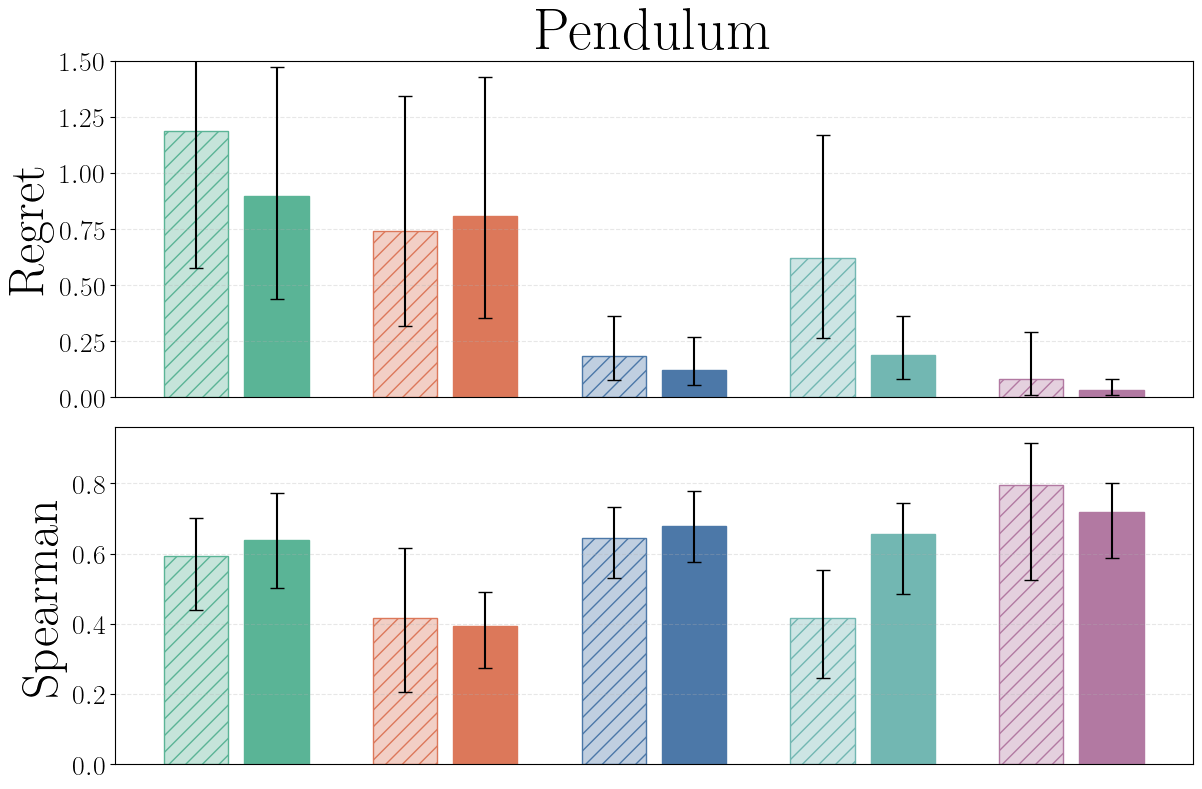

In [24]:
plot_benchmarks(pipeline = 'pendulum_pipeline', seeds = list(range(0,10)), ylim = 1.5, save = True, show_x_labels=False)

Processing transformer seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing gru seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing mlp seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing resnet seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing ode seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...


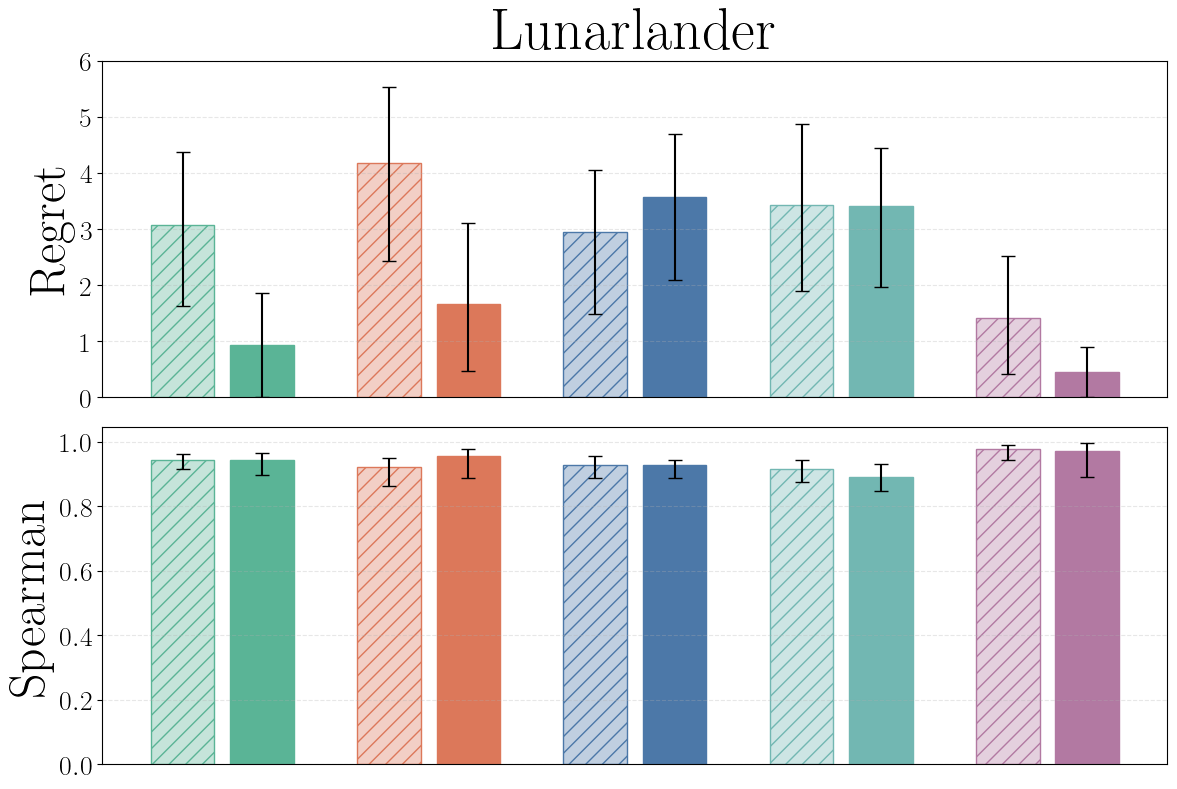

In [19]:
plot_benchmarks(pipeline = 'lunarlander_pipeline', seeds = list(range(10,20)), ylim = 6, save = True, show_x_labels=False)

Processing transformer seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing gru seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing mlp seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing resnet seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing ode seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...


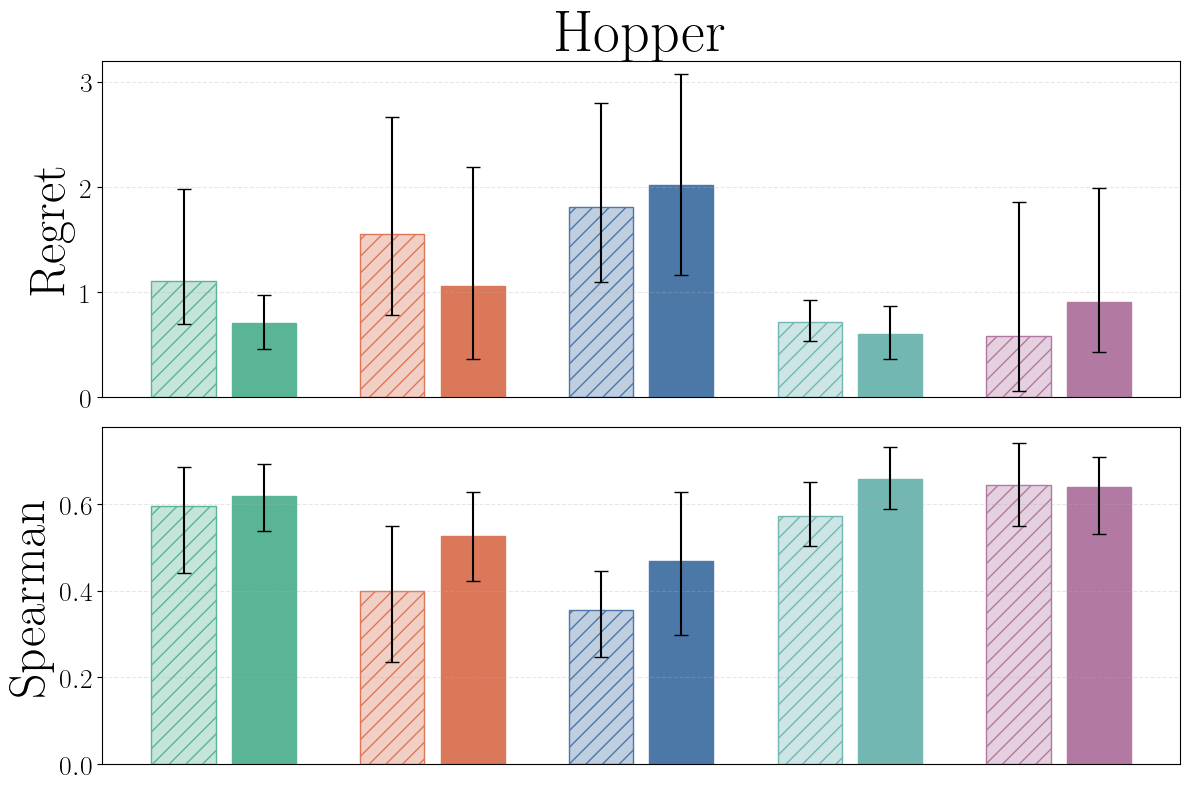

In [30]:
plot_benchmarks(pipeline = 'hopper_pipeline', seeds = list(range(2,12)), ylim = 3.2, save = True, show_x_labels=False)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...


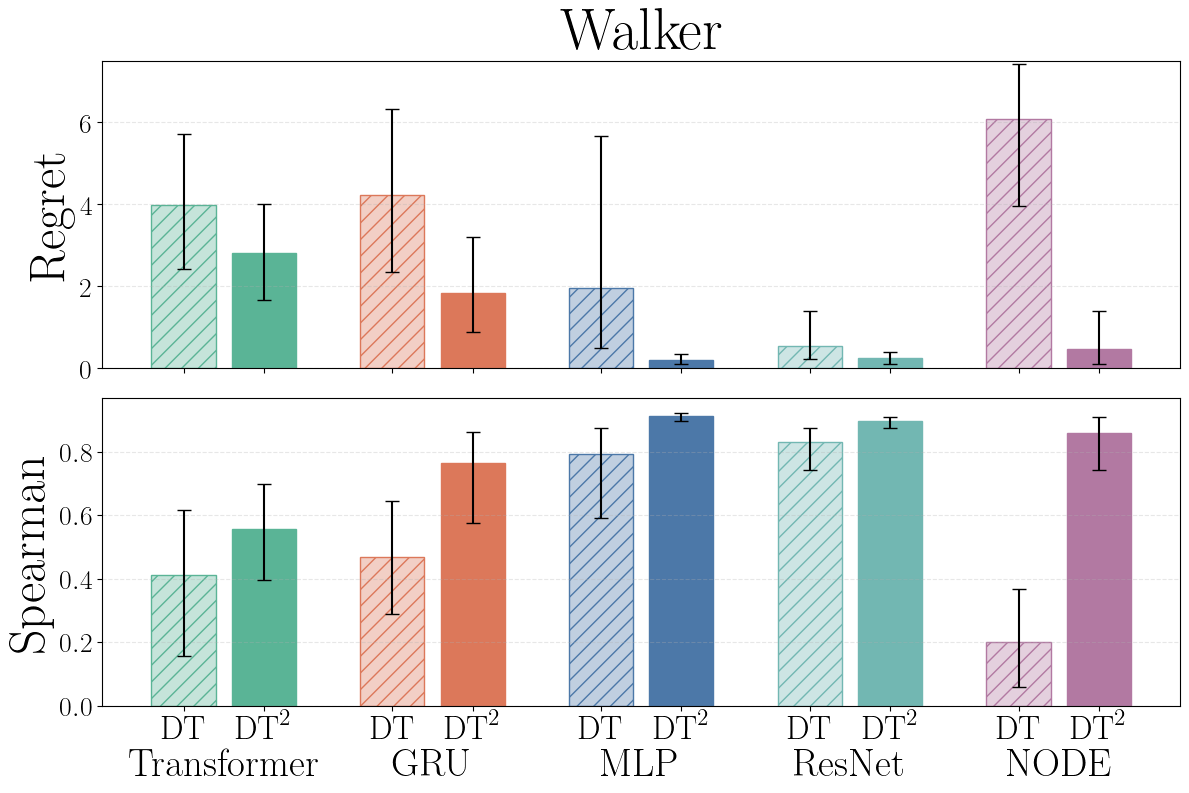

In [37]:
plot_benchmarks(pipeline = 'walker_pipeline', seeds = list(range(0,20)), ylim = 7.5, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...


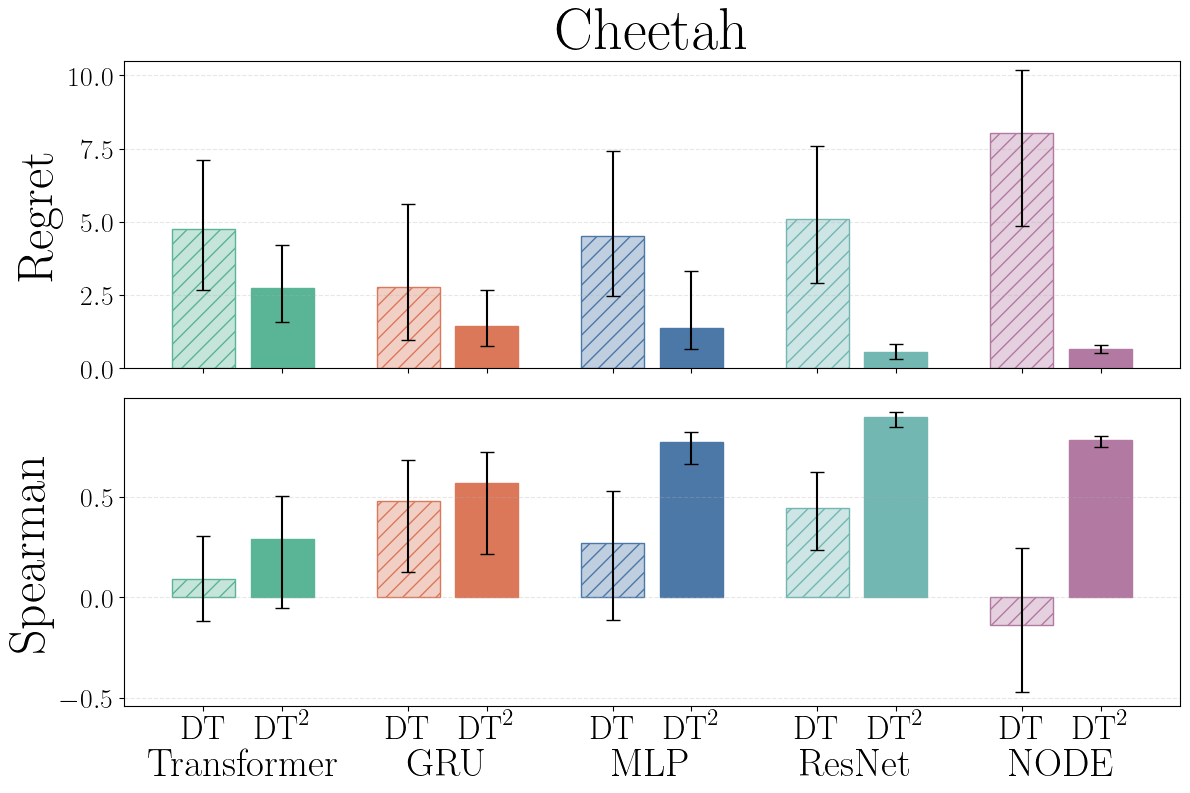

In [40]:
plot_benchmarks(pipeline = 'cheetah_pipeline', seeds = list(range(0,20)), ylim = 10.5, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


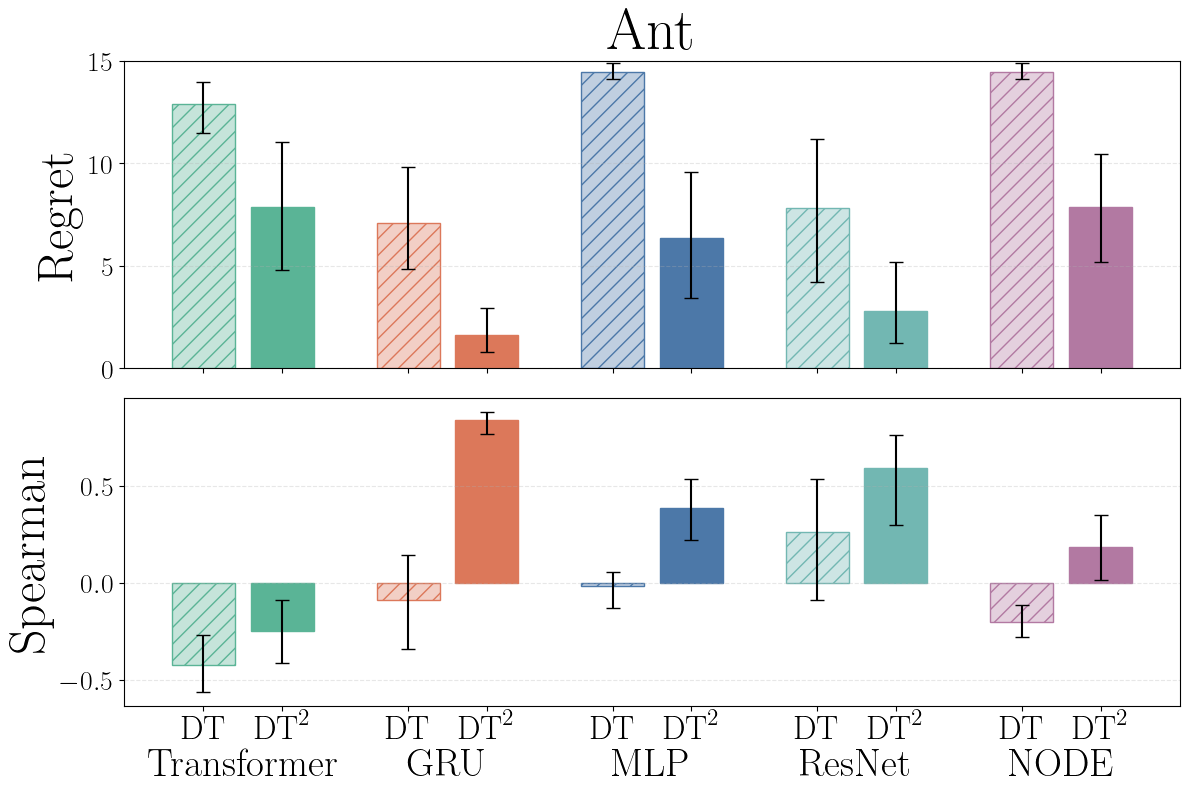

In [42]:
plot_benchmarks(pipeline = 'ant_pipeline', seeds = list(range(0,10)), ylim = 15, save = True)

In [130]:
#graphing pane
import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

# ============== CONFIGURATION ==============
PIPELINE = "pendulum_pipeline"  # Change this to switch pipelines (e.g., "lunarlander_pipeline", "cancer_pipeline")
SEEDS = list(range(0, 10))
# ===========================================

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

# VaGraM metric path for VAML files
VAGRAM_METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "VaGraM": ["dynamics", "value_aware"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def process_single_seed_vagram(file_path):
    """Parses a single VAML JSON file and calculates rankings and regrets for VaGraM."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    for entry in results:
        for method, path in VAGRAM_METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results_MSE(seed_range, folder, pipeline=PIPELINE):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./camera_ready/{pipeline}/{folder}/summary_MSE_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

def aggregate_results_vagram(seed_range, pipeline=PIPELINE):
    """Iterates over seeds for resnet folder, processes VAML files, and aggregates VaGraM results."""
    pattern = f"./test/{pipeline}/mlp/summary_VAML_{{}}.json"
    agg_rankings = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    agg_regrets = {"VaGraM": []}
    valid_seeds = []
    print(f"Processing VaGraM (VAML) seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed_vagram(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        agg_regrets["VaGraM"].append(single_res["regrets"]["VaGraM"])
    return agg_rankings, agg_regrets, valid_seeds

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

def collect_performance_bca_vagram(rankings, regrets, n_boot=10000):
    """Collect BCA stats for VaGraM method."""
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    method = "VaGraM"
    
    if method not in regrets or len(regrets[method]) == 0:
        return results
    
    reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
    spearman_scores = []
    pass1_scores = []
    for true_sort, method_sort in zip(true_rankings, rankings[method]):
        r_true = to_rank_vector(true_sort)
        r_method = to_rank_vector(method_sort)
        corr, _ = stats.spearmanr(r_true, r_method)
        spearman_scores.append(corr)
        pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
    corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
    p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
    results[method] = {
        "regret": (reg_mean, reg_ci),
        "spearman": (corr_mean, corr_ci),
        "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
    }
    return results

# Compute and plot for each model folder

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

def plot_benchmarks_mse(pipeline = PIPELINE, seeds = SEEDS, ylim = 1.5, save=False):
    MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
    metrics = [("regret", r"$\mathrm{Regret}$"), ("spearman", r"$\mathrm{Spearman}$")]

    results_by_folder = {}
    for folder in MODEL_FOLDERS:
        rankings, regrets, processed_seeds = aggregate_results_MSE(seeds, folder, pipeline)
        if not processed_seeds:
            print(f"No valid seeds for {folder}; skipping.")
            continue
        results_by_folder[folder] = collect_performance_bca(rankings, regrets)

    # Aggregate VaGraM results from resnet/summary_VAML_* files
    vagram_rankings, vagram_regrets, vagram_seeds = aggregate_results_vagram(seeds, pipeline)
    vagram_results = collect_performance_bca_vagram(vagram_rankings, vagram_regrets)

    methods = ["supervised", "kendall"]  # Methods per architecture group
    folders = list(results_by_folder.keys())

    # Helper to map folder names to Capitalized + TeX versions
    def format_folder_name(name):
        # Just simple capitalization or specific overrides if needed
        if name.lower() == "gru":
            return r"$\mathrm{GRU}$"
        if name.lower() == "mlp":
            return r"$\mathrm{MLP}$"
        if name.lower() == "ode":
            return r"$\mathrm{NODE}$"
        # For others like Transformer, ResNet, just Title case
        formatted = name.replace("resnet", "ResNet").capitalize()
        if name.lower() == "resnet": formatted = "ResNet"
        return rf"$\mathrm{{{formatted}}}$"

    if not folders:
        print("No results to plot.")
    else:
        group_gap = 0.6
        group_size = len(methods)  # 2 bars per architecture group
        
        # Positions for architecture groups
        positions = []
        for i, folder in enumerate(folders):
            base = i * (group_size + group_gap)
            for j in range(group_size):
                positions.append(base + j)
        centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
        
        # Position for VaGraM bar (rightmost, with extra gap)
        vagram_gap = 1.2  # Extra gap before VaGraM
        vagram_position = positions[-1] + vagram_gap + 1
        
        palette = [
            (90/255, 180/255, 150/255),   # your darker mint (Option 1)
            (220/255, 120/255, 90/255),   # your coral
            (76/255, 120/255, 168/255),   # deep blue
            (114/255, 183/255, 178/255),  # slate teal
            (178/255, 121/255, 162/255),  # muted purple
            (238/255, 202/255, 59/255),   # mustard
        ]
        folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
        hatch_map = {"supervised": "//", "kendall": None}
        
        face_colors = []
        edge_colors = []
        hatches = []
        for folder in folders:
            base_color = folder_colors[folder]
            for m in methods:
                if m == "supervised":
                    face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])
                else:
                    face_colors.append(base_color)
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])

        fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(max(8, 2 * len(folders) + 2), 8), sharex=True)
        # Format pipeline name for title (e.g., "pendulum_pipeline" -> "Pendulum")
        plot_title = pipeline.replace("_pipeline", "").replace("_", " ").title()
        axes[0].set_title(plot_title, fontsize=32)

        for ax, (metric, label) in zip(axes, metrics):
            means = []
            lowers = []
            uppers = []
            # Architecture group bars
            for folder in folders:
                res = results_by_folder[folder]
                for m in methods:
                    if m not in res:
                        means.append(np.nan)
                        lowers.append(np.nan)
                        uppers.append(np.nan)
                        continue
                    mean, ci = res[m][metric]
                    means.append(mean)
                    lowers.append(mean - ci[0])
                    uppers.append(ci[1] - mean)
            
            # Plot architecture bars
            for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
                ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1, rasterized=True)
            
            # Plot VaGraM bar (grey, standalone)
            """if "VaGraM" in vagram_results:
                vagram_mean, vagram_ci = vagram_results["VaGraM"][metric]
                vagram_lo = vagram_mean - vagram_ci[0]
                vagram_up = vagram_ci[1] - vagram_mean
                ax.bar(vagram_position, vagram_mean, yerr=[[vagram_lo], [vagram_up]], capsize=5, 
                    color="grey", edgecolor="dimgrey", linewidth=1, rasterized=True)"""
            
            ax.set_ylabel(label, fontsize=28)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            ax.tick_params(axis='y', labelsize=20)
            if metric == "regret":
                ax.set_ylim(0, ylim)

        # Level 1 tick labels: DT (supervised) / DT^2 (kendall) for architecture groups, VaGraM for baseline
        bar_labels = []
        for _ in folders:
            bar_labels.extend([r"$\mathrm{DT}$", r"$\mathrm{DT}^2$"])
        #bar_labels.append(r"$\mathrm{VaGraM}$")
        
        all_positions = positions # + [vagram_position]
        axes[-1].set_xticks(all_positions)
        axes[-1].set_xticklabels(bar_labels, rotation=0, ha="center", fontsize=24)

        # Level 2 labels: architecture names below the axis
        trans = axes[-1].get_xaxis_transform()
        for center, folder in zip(centers, folders):
            display_name = format_folder_name(folder)
            axes[-1].text(center, -0.14, display_name, transform=trans, ha="center", va="top", fontsize=28)

        folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=format_folder_name(f)) for f in folders]
        method_handles = [
            Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
            Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
            #Patch(facecolor="grey", edgecolor="dimgrey", label="VaGraM", linewidth=1),
        ]
        
        fig.tight_layout()
        if save:
            plt.savefig(f'plots/{pipeline}_mse.pdf')

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


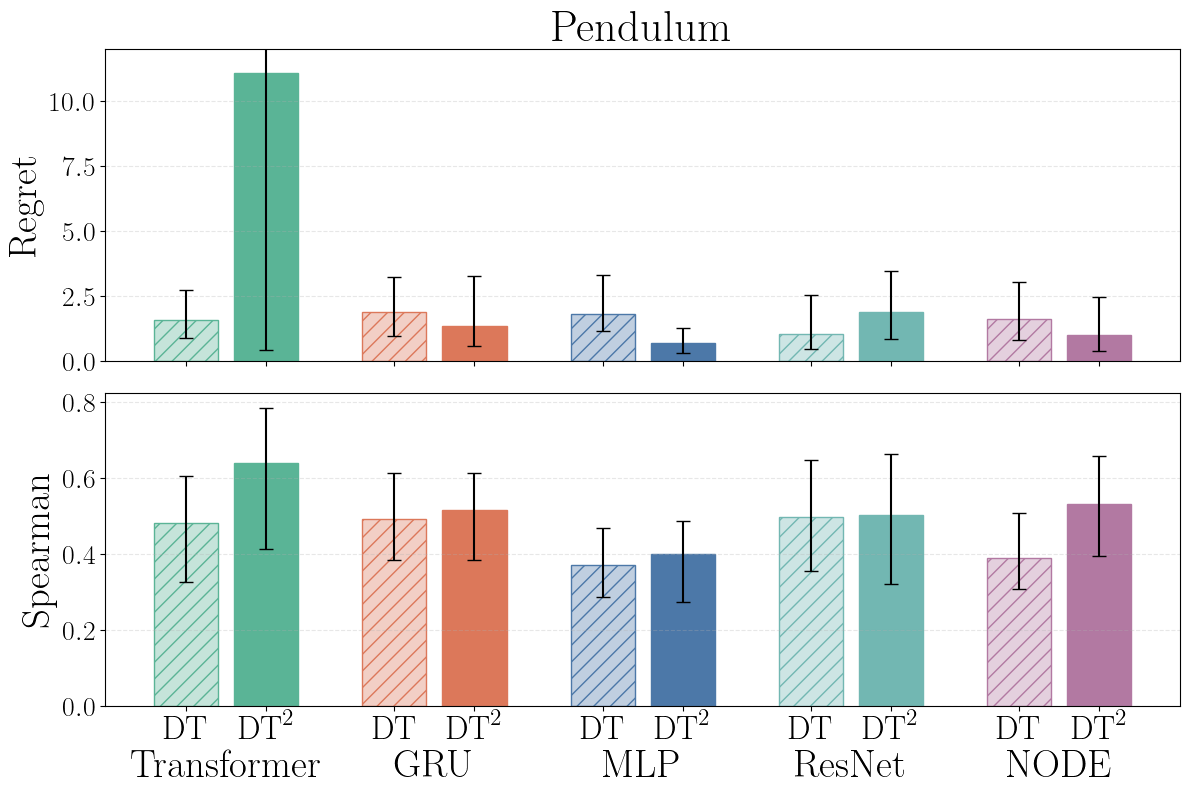

In [121]:
plot_benchmarks_mse(pipeline = 'pendulum_pipeline', seeds = list(range(0,10)), ylim = 12, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


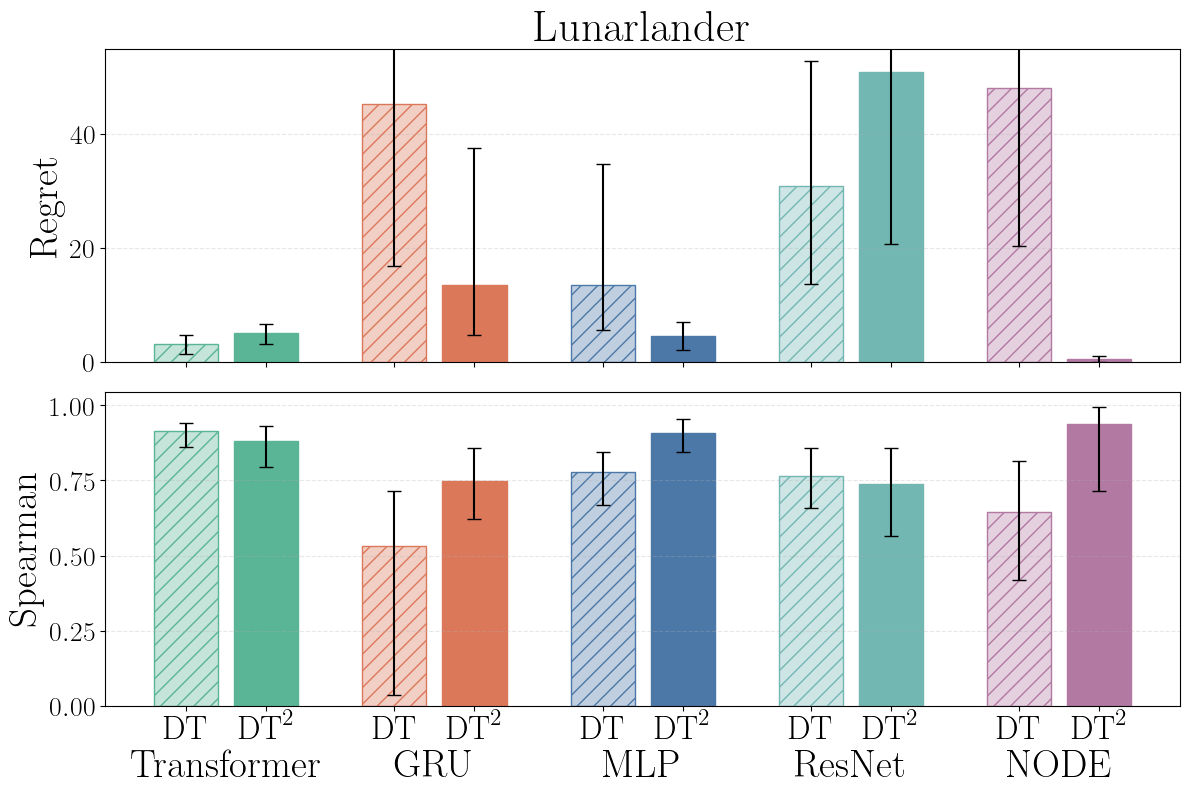

In [136]:
plot_benchmarks_mse(pipeline = 'lunarlander_pipeline', seeds = list(range(0,10)), ylim = 55, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


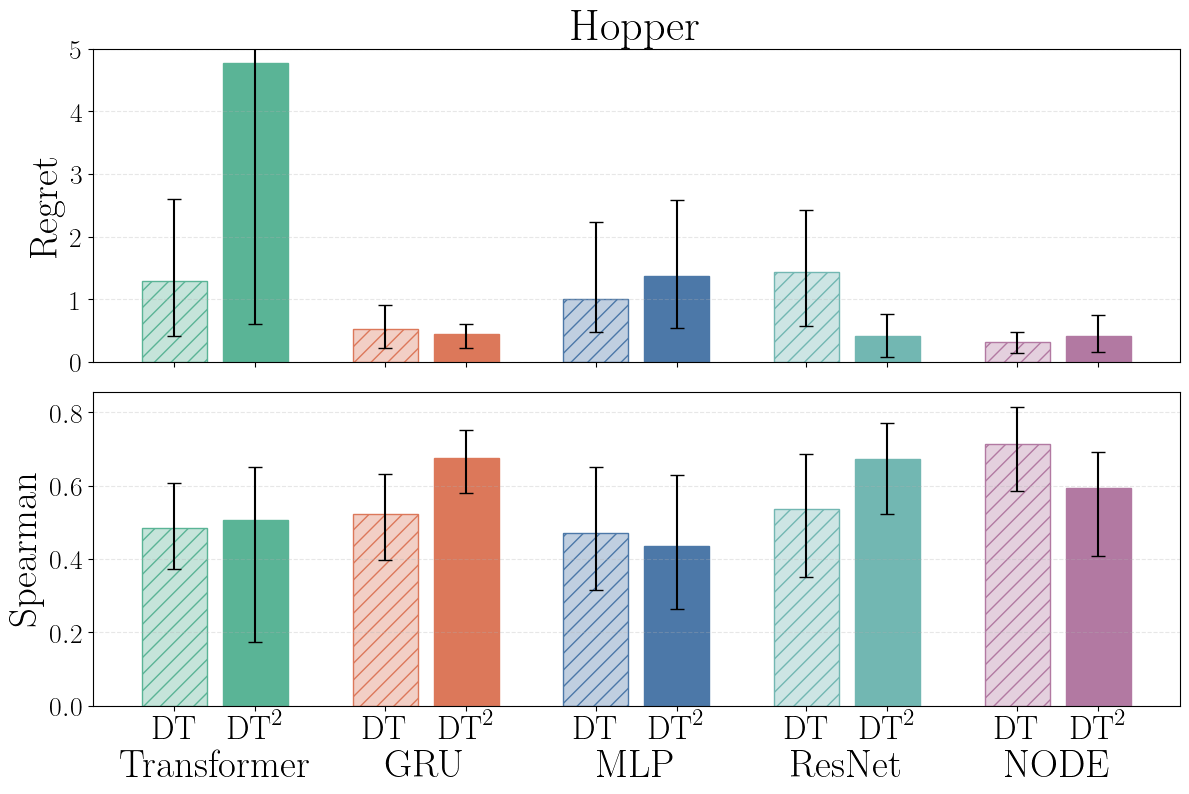

In [122]:
plot_benchmarks_mse(pipeline = 'hopper_pipeline', seeds = list(range(0,10)), ylim = 5, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


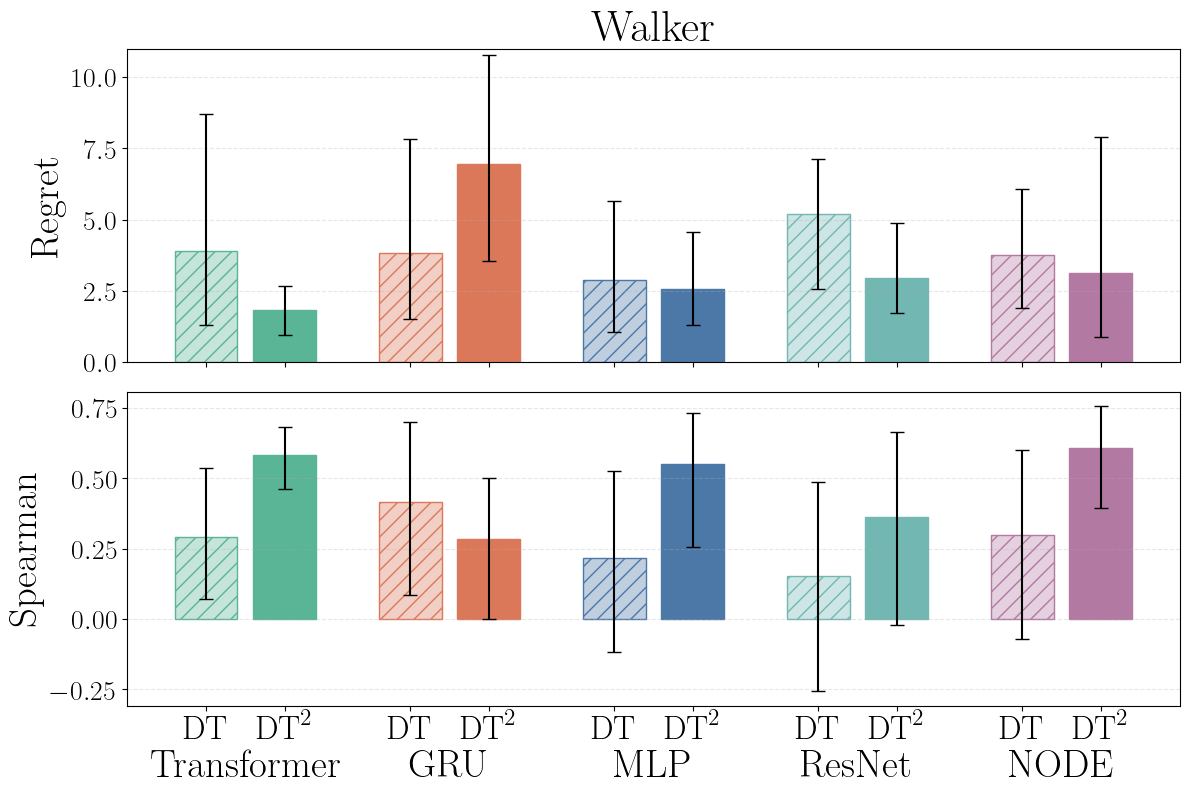

In [124]:
plot_benchmarks_mse(pipeline = 'walker_pipeline', seeds = list(range(0,10)), ylim = 11, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


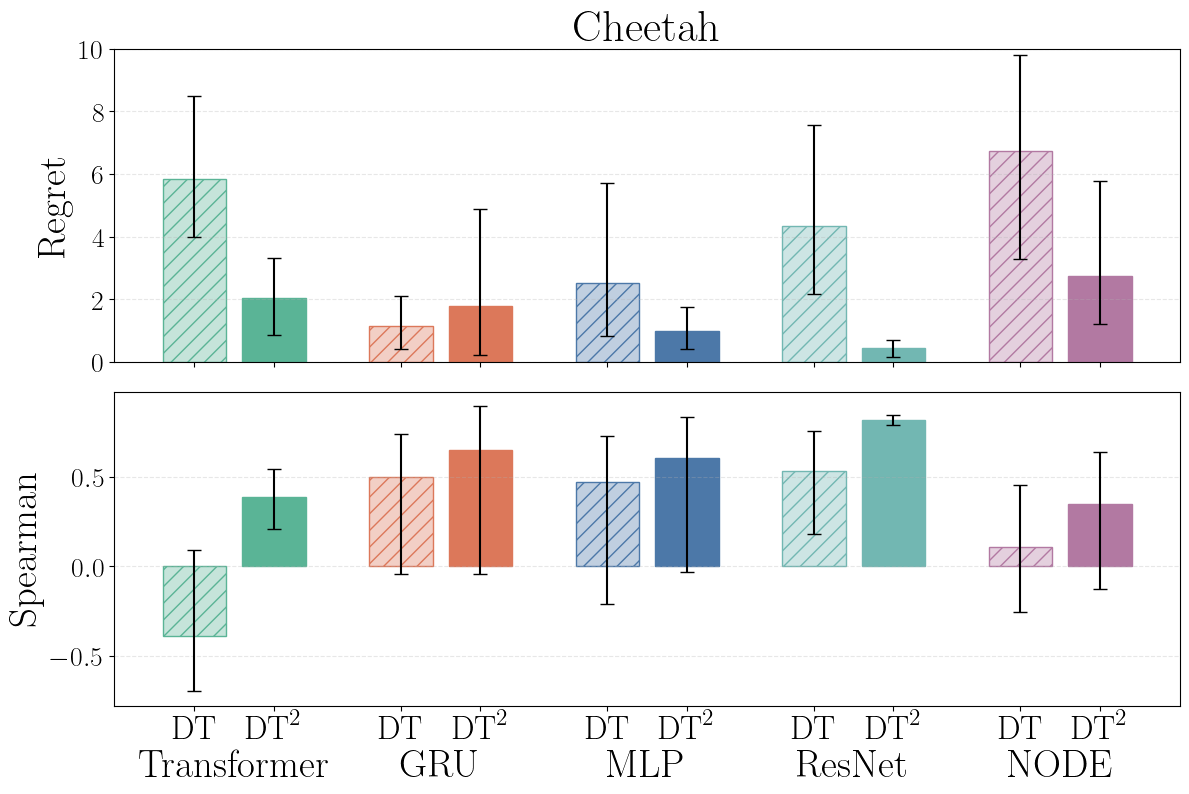

In [129]:
plot_benchmarks_mse(pipeline = 'cheetah_pipeline', seeds = list(range(0,10)), ylim = 10, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


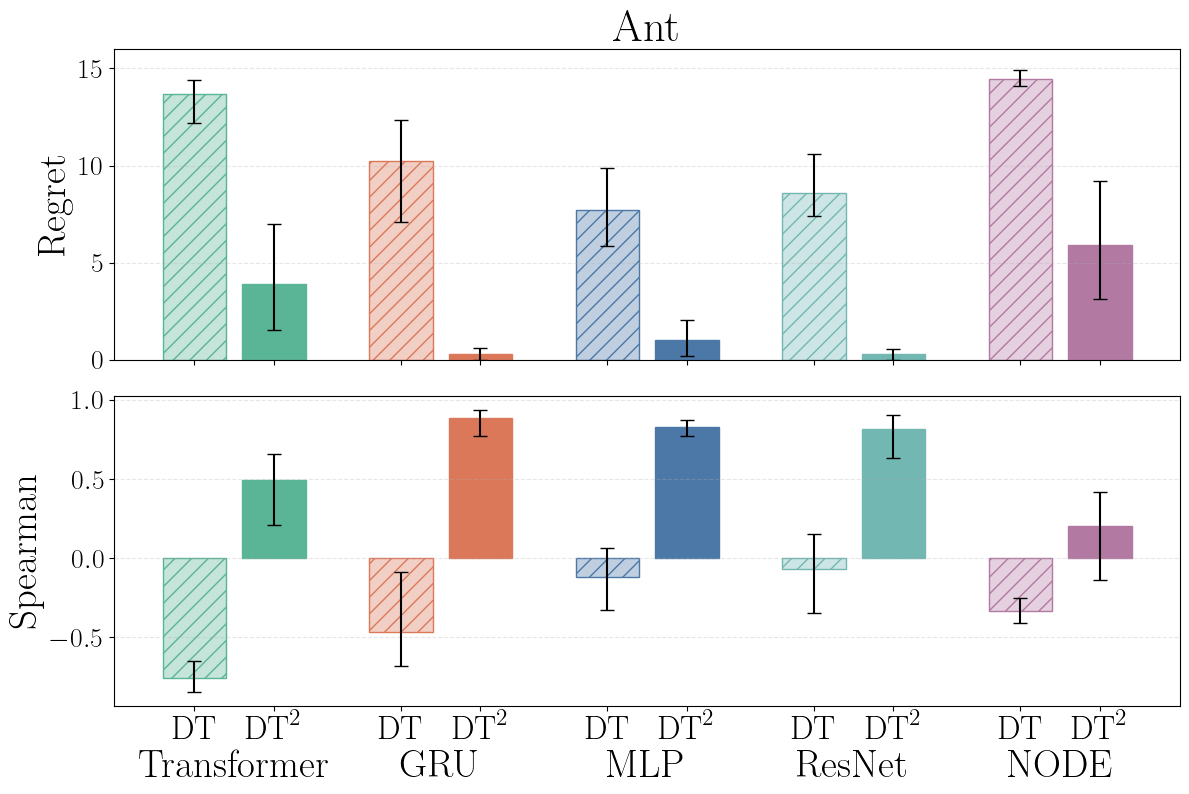

In [128]:
plot_benchmarks_mse(pipeline = 'ant_pipeline', seeds = list(range(0,10)), ylim = 16, save = True)

# MSE Analysis

In [117]:
import json
import os
import numpy as np 
from scipy import stats

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through summary files, averages specific metrics, 
    and returns lists of those averages.
    """
    
    # Lists to store the final averages per seed
    avg_kendall_mses = []
    found_seeds = []

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_0.99_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        # Check if file exists
        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Check if 'results' key exists
            if "results" not in data:
                print(f"  [Warning] No 'results' key in {filename}")
                continue

            results = data["results"]
            
            if not results:
                print(f"  [Warning] 'results' list is empty in {filename}")
                continue

            # Temporary lists to hold values for the current file (current seed)
            file_kendall_vals = []

            for entry in results:
                # Access: dynamics -> ranking_new_mse -> kendall
                try:
                    k_mse = entry["dynamics"]["ranking_new_mse"]["kendall"]
                    #k_mse = entry["dynamics"]["supervised_mse"]
                    file_kendall_vals.append(k_mse)
                except KeyError:
                    pass 

            if file_kendall_vals:
                avg_kendall = sum(file_kendall_vals) / len(file_kendall_vals)
                avg_kendall_mses.append(avg_kendall)
            else:
                avg_kendall_mses.append(None)

            found_seeds.append(seed)

        except json.JSONDecodeError:
            print(f"  [Error] Could not decode JSON in {filename}")
        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_kendall_mses

# ==========================================
# Configuration
# ==========================================
# The base folder containing the method subfolders
BASE_FOLDER = './test/cheetah_pipeline' 
METHODS = ['resnet']

START_SEED = 0
END_SEED = 4

# ==========================================
# Execution
# ==========================================
print("-" * 50)
print(f"Processing Methods: {METHODS}")
print("-" * 50)

for method in METHODS:
    # Construct the full path for the specific method
    method_path = os.path.join(BASE_FOLDER, method)

    if not os.path.exists(method_path):
        print(f"Skipping '{method}': Folder not found at {method_path}")
        continue

    # Get the raw lists per seed
    seeds, kendall_list = process_results(method_path, START_SEED, END_SEED)
    
    # Filter out None values to calculate valid means
    valid_kendall = [x for x in kendall_list if x is not None]

    if not valid_kendall:
        print(f"Skipping '{method}': No valid data extracted.")
        continue

    # Calculate Mean and Standard Error across all seeds for this method
    mean_mse = np.mean(valid_kendall)
    se_mse = stats.sem(valid_kendall) if len(valid_kendall) > 1 else 0.0

    print(f"Method: {method:<15} | Seeds Found: {len(seeds)}")
    print(f"  > Avg MSE:  {mean_mse} ± {se_mse} (S.E.)")
    print("-" * 20)

--------------------------------------------------
Processing Methods: ['resnet']
--------------------------------------------------
Method: resnet          | Seeds Found: 5
  > Avg MSE:  0.5668877422809601 ± 0.056472225416760176 (S.E.)
--------------------


In [49]:
import json
import os
import numpy as np 

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through VAML summary files, averages specific metrics, 
    and returns lists of those averages.
    """
    
    # Lists to store the final averages per seed
    avg_vaml_mses = []
    found_seeds = []

    # print(f"Processing seeds {start_seed} to {end_seed} in '{folder_path}'...")

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_VAML_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        # Check if file exists
        if not os.path.exists(file_path):
            # print(f"  [Warning] File not found: {filename}")
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Check if 'results' key exists
            if "results" not in data:
                print(f"  [Warning] No 'results' key in {filename}")
                continue

            results = data["results"]
            
            if not results:
                print(f"  [Warning] 'results' list is empty in {filename}")
                continue

            # Temporary lists to hold values for the current file (current seed)
            file_sup_vals = []
            file_vaml_vals = []

            for entry in results:

                try:
                    v_mse = entry["dynamics"]["value_aware_mse"]
                    file_vaml_vals.append(v_mse)
                except KeyError:
                    pass

            if file_vaml_vals:
                avg_vaml = sum(file_vaml_vals) / len(file_vaml_vals)
                avg_vaml_mses.append(avg_vaml)
            else:
                avg_vaml_mses.append(None)
            found_seeds.append(seed)

        except json.JSONDecodeError:
            print(f"  [Error] Could not decode JSON in {filename}")
        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_vaml_mses

# ==========================================
# Configuration
# ==========================================
# The base folder containing the method subfolders
BASE_FOLDER = './test/pendulum_pipeline' 
METHODS = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

START_SEED = 0
END_SEED = 4

# ==========================================
# Execution
# ==========================================

print("-" * 50)
print(f"Processing Methods: {METHODS}")
print("-" * 50)

for method in METHODS:
    # Construct the full path for the specific method
    method_path = os.path.join(BASE_FOLDER, method)
    
    if not os.path.exists(method_path):
        print(f"Skipping '{method}': Folder not found at {method_path}")
        continue

    # Get the raw lists per seed
    seeds, vaml_list = process_results(method_path, START_SEED, END_SEED)
    
    # Filter out None values to calculate valid means
    valid_vaml = [x for x in vaml_list if x is not None]

    # Calculate Grand Averages across all seeds for this method
    mean_vaml = np.mean(valid_vaml)

    
    print(f"Method: {method:<15} | Seeds Found: {len(seeds)}")
    print(f"  > Mean VAML:    {mean_vaml:.6f}")
    print("-" * 20)

--------------------------------------------------
Processing Methods: ['transformer', 'gru', 'ode', 'mlp', 'resnet']
--------------------------------------------------
Method: transformer     | Seeds Found: 0
  > Mean VAML:    nan
--------------------
Method: gru             | Seeds Found: 0
  > Mean VAML:    nan
--------------------
Method: ode             | Seeds Found: 5
  > Mean VAML:    0.000007
--------------------
Method: mlp             | Seeds Found: 5
  > Mean VAML:    0.000006
--------------------
Method: resnet          | Seeds Found: 5
  > Mean VAML:    0.000021
--------------------


In [143]:
import json
import os
import numpy as np 

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through summary files, averages specific metrics, 
    and returns lists of those averages per seed.
    """
    
    avg_supervised_mses = []
    avg_kendall_mses = []
    avg_hinge_mses = []
    avg_listnet_mses = []
    found_seeds = []

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            if "results" not in data or not data["results"]:
                continue

            results = data["results"][1:]
            
            # Temporary lists for current file
            file_sup_vals = []
            file_kendall_vals = []
            file_hinge_vals = []
            file_listnet_vals = []

            for entry in results:
                # Access: dynamics -> supervised_mse
                try:
                    s_mse = entry["dynamics"]["supervised_mse"]
                    file_sup_vals.append(s_mse)
                except KeyError:
                    pass 

                # Access: dynamics -> ranking_new_mse -> kendall
                try:
                    k_mse = entry["dynamics"]["ranking_new_mse"]["kendall"]
                    file_kendall_vals.append(k_mse)
                except KeyError:
                    pass

                # Access: dynamics -> ranking_new_mse -> hinge
                try:
                    h_mse = entry["dynamics"]["ranking_new_mse"]["hinge"]
                    file_hinge_vals.append(h_mse)
                except KeyError:
                    pass

                # Access: dynamics -> ranking_new_mse -> listnet
                try:
                    l_mse = entry["dynamics"]["ranking_new_mse"]["listnet"]
                    file_listnet_vals.append(l_mse)
                except KeyError:
                    pass

            # Calculate Averages for this file (Seed)
            if file_sup_vals:
                avg_sup = sum(file_sup_vals) / len(file_sup_vals)
                avg_supervised_mses.append(avg_sup)
            else:
                avg_supervised_mses.append(None) 

            if file_kendall_vals:
                avg_kendall = sum(file_kendall_vals) / len(file_kendall_vals)
                avg_kendall_mses.append(avg_kendall)
            else:
                avg_kendall_mses.append(None)

            if file_hinge_vals:
                avg_hinge = sum(file_hinge_vals) / len(file_hinge_vals)
                avg_hinge_mses.append(avg_hinge)
            else:
                avg_hinge_mses.append(None)

            if file_listnet_vals:
                avg_listnet = sum(file_listnet_vals) / len(file_listnet_vals)
                avg_listnet_mses.append(avg_listnet)
            else:
                avg_listnet_mses.append(None)

            found_seeds.append(seed)

        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_supervised_mses, avg_kendall_mses, avg_hinge_mses, avg_listnet_mses

# ==========================================
# Configuration
# ==========================================
PIPELINES = [
    './test/cheetah_pipeline', 
    './test/walker_pipeline', 
    './test/hopper_pipeline', 
    './test/pendulum_pipeline', 
    './test/lunarlander_pipeline',
    './test/ant_pipeline'
]

METHODS = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

# Define seeds per pipeline
PIPELINE_SEEDS = {
    './test/cheetah_pipeline': (0, 20),
    './test/walker_pipeline': (0, 20),
    './test/hopper_pipeline': (2, 12),
    './test/pendulum_pipeline': (0, 10),
    './camera_ready/lunarlander_pipeline': (10, 20),
    './test/ant_pipeline': (0, 10)
}

# ==========================================
# Execution
# ==========================================
global_results = {}
all_supervised_mses = []
all_kendall_mses = []
all_hinge_mses = []
all_listnet_mses = []

print("STARTING PROCESSING...")
print("=" * 60)

for pipeline in PIPELINES:
    print(f"\nProcessing Pipeline: {pipeline}")
    print("-" * 60)
    
    # Get seeds for this pipeline
    start_seed, end_seed = PIPELINE_SEEDS.get(pipeline, (0, 5))
    print(f"  Using seeds {start_seed} to {end_seed}")
    
    pipeline_ratios = {}
    
    for method in METHODS:
        # Construct path: e.g. ./test/cheetah_pipeline/transformer
        method_path = os.path.join(pipeline, method)
        
        if not os.path.exists(method_path):
            print(f"  [Skipping] '{method}': Folder not found.")
            continue

        # Get raw data
        seeds, sup_list, kendall_list, hinge_list, listnet_list = process_results(method_path, start_seed, end_seed)
        
        # Filter Nones
        valid_sup = [x for x in sup_list if x is not None]
        valid_kendall = [x for x in kendall_list if x is not None]
        valid_hinge = [x for x in hinge_list if x is not None]
        valid_listnet = [x for x in listnet_list if x is not None]

        if not valid_sup or not valid_kendall:
            print(f"  [Skipping] '{method}': No valid data.")
            continue

        # Calculate Means across seeds
        mean_sup = np.mean(valid_sup)
        mean_kendall = np.mean(valid_kendall)
        
        # Collect for grand averages
        all_supervised_mses.extend(valid_sup)
        all_kendall_mses.extend(valid_kendall)
        all_hinge_mses.extend(valid_hinge)
        all_listnet_mses.extend(valid_listnet)

        # Calculate Ratio
        ratio = 0.0
        if mean_sup > 0:
            ratio = mean_kendall / mean_sup
        
        pipeline_ratios[method] = ratio
        
        print(f"  Method: {method:<12} | Seeds: {len(seeds):<2} | Ratio: {ratio:.5f}")

    # Store results for this pipeline
    global_results[pipeline] = pipeline_ratios
    
    # Calculate average ratio for this pipeline (across its methods)
    if pipeline_ratios:
        avg_pipe_ratio = np.mean(list(pipeline_ratios.values()))
        print("-" * 60)
        print(f"  >> Average Ratio for {os.path.basename(pipeline)}: {avg_pipe_ratio:.5f}")
    else:
        print("  >> No data found for this pipeline.")
    
    print("=" * 60)

# ==========================================
# Final Report & Grand Average
# ==========================================
print("\nFINAL SUMMARY DICTIONARY")
print(json.dumps(global_results, indent=2))

print("\nFINAL AVERAGES (Across all methods per pipeline):")
all_collected_ratios = []

for pipe, ratios in global_results.items():
    if ratios:
        # Save for grand total
        all_collected_ratios.extend(ratios.values())
        
        avg = np.mean(list(ratios.values()))
        print(f"{pipe:<30}: {avg:.5f}")
    else:
        print(f"{pipe:<30}: N/A")

# ---------------------------------------------------------
# GRAND AVERAGE CALCULATIONS
# ---------------------------------------------------------
print("\n" + "*" * 50)
if all_collected_ratios:
    grand_avg = np.mean(all_collected_ratios)
    print(f"GRAND AVERAGE RATIO (Across all {len(all_collected_ratios)} data points): {grand_avg:.5f}")
else:
    print("No ratios collected to calculate a grand average.")

if all_supervised_mses:
    grand_avg_supervised = np.mean(all_supervised_mses)
    print(f"GRAND AVERAGE SUPERVISED MSE (Across all {len(all_supervised_mses)} data points): {grand_avg_supervised:.5f}")
else:
    print("No supervised MSEs collected.")

if all_kendall_mses:
    grand_avg_kendall = np.mean(all_kendall_mses)
    print(f"GRAND AVERAGE KENDALL MSE (Across all {len(all_kendall_mses)} data points): {grand_avg_kendall:.5f}")
else:
    print("No Kendall MSEs collected.")

if all_hinge_mses:
    grand_avg_hinge = np.mean(all_hinge_mses)
    print(f"GRAND AVERAGE HINGE MSE (Across all {len(all_hinge_mses)} data points): {grand_avg_hinge:.5f}")
else:
    print("No Hinge MSEs collected.")

if all_listnet_mses:
    grand_avg_listnet = np.mean(all_listnet_mses)
    print(f"GRAND AVERAGE LISTNET MSE (Across all {len(all_listnet_mses)} data points): {grand_avg_listnet:.5f}")
else:
    print("No Listnet MSEs collected.")
    
print("*" * 50)


STARTING PROCESSING...

Processing Pipeline: ./test/cheetah_pipeline
------------------------------------------------------------
  Using seeds 0 to 20
  Method: transformer  | Seeds: 11 | Ratio: 1.36961
  Method: gru          | Seeds: 11 | Ratio: 1.07512
  Method: ode          | Seeds: 10 | Ratio: 1.05672
  Method: mlp          | Seeds: 11 | Ratio: 1.02048
  Method: resnet       | Seeds: 11 | Ratio: 1.10401
------------------------------------------------------------
  >> Average Ratio for cheetah_pipeline: 1.12519

Processing Pipeline: ./test/walker_pipeline
------------------------------------------------------------
  Using seeds 0 to 20
  Method: transformer  | Seeds: 14 | Ratio: 0.88129
  Method: gru          | Seeds: 14 | Ratio: 1.37808
  Method: ode          | Seeds: 10 | Ratio: 0.96315
  Method: mlp          | Seeds: 11 | Ratio: 1.00194
  Method: resnet       | Seeds: 10 | Ratio: 1.03713
------------------------------------------------------------
  >> Average Ratio for walker

In [146]:
import json
import os
import numpy as np
from scipy import stats

# ==========================================
# CONFIGURATION
# ==========================================
PIPELINES = [
    './test/cheetah_pipeline', 
    './test/walker_pipeline', 
    './test/hopper_pipeline', 
    './test/pendulum_pipeline', 
    './camera_ready/lunarlander_pipeline',
    './test/ant_pipeline'
]

ARCHITECTURES = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

# All four metrics
METRIC_PATHS = {
    "supervised": ["dynamics", "supervised"],
    "kendall":    ["dynamics", "ranking_new", "kendall"],
    "hinge":      ["dynamics", "ranking_new", "hinge"],
    "listnet":    ["dynamics", "ranking_new", "listnet"]
}

GT_KEY = ["env_mc"]

# ==========================================
# GLOBAL AGGREGATORS
# ==========================================
grand_stats = {
    "supervised": {"regrets": [], "correlations": []},
    "kendall":    {"regrets": [], "correlations": []},
    "hinge":      {"regrets": [], "correlations": []},
    "listnet":    {"regrets": [], "correlations": []}
}

# ==========================================
# HELPERS
# ==========================================
def get_nested_value(dictionary, keys):
    val = dictionary
    try:
        for key in keys:
            if val is None: return -np.inf
            val = val[key]
        return float(val) if val is not None else -np.inf
    except (KeyError, TypeError, ValueError):
        return -np.inf

def calculate_metrics_for_file(file_path):
    """
    Calculates Regret and Spearman Correlation for a single file.
    """
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except:
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    # 1. Extract Ground Truth
    gt_scores = np.array([get_nested_value(e, GT_KEY) for e in results])

    if np.all(np.isinf(gt_scores)):
        return None
    
    true_optimal_val = np.max(gt_scores)
    file_metrics = {"regrets": {}, "correlations": {}}

    for method_name, json_path in METRIC_PATHS.items():
        # Extract scores for this metric
        method_scores = np.array([get_nested_value(e, json_path) for e in results])

        # --- Regret Calculation (Higher Score = Better Policy) ---
        ranking_indices = np.argsort(method_scores)[::-1]
        selected_idx = ranking_indices[0]
        selected_policy_true_val = gt_scores[selected_idx]

        if np.isinf(selected_policy_true_val):
            regret = np.nan
        else:
            regret = true_optimal_val - selected_policy_true_val
        
        file_metrics["regrets"][method_name] = regret

        # --- Correlation Calculation ---
        if len(method_scores) > 1:
            corr, _ = stats.spearmanr(method_scores, gt_scores)
            file_metrics["correlations"][method_name] = corr if not np.isnan(corr) else 0.0
        else:
            file_metrics["correlations"][method_name] = 0.0

    return file_metrics

# ==========================================
# MAIN EXECUTION
# ==========================================
header = f"{'PIPELINE':<25} | {'ARCH':<12} | {'SUP REG':<9} | {'SUP CORR':<9} | {'KEN REG':<9} | {'KEN CORR':<9} | {'HNG REG':<9} | {'HNG CORR':<9} | {'LST REG':<9} | {'LST CORR':<9} | {'N'}"
print(header)
print("-" * len(header))

for pipeline in PIPELINES:
    pipeline_name = os.path.basename(pipeline)
    
    # -------------------------------------------------
    # DYNAMIC SEED SELECTION
    # -------------------------------------------------
    if 'pendulum' in pipeline_name:
        current_seeds = list(range(0, 10))
    elif 'ant' in pipeline_name:
        current_seeds = list(range(0, 10)) 
    elif 'lunarlander' in pipeline_name:
        current_seeds = list(range(0, 10))
    elif 'hopper' in pipeline_name:
        current_seeds = list(range(2, 12))
    else:
        current_seeds = list(range(0, 20))
    
    for arch in ARCHITECTURES:
        folder_path = os.path.join(pipeline, arch)
        
        if not os.path.exists(folder_path):
            continue
        
        local_regrets = {"supervised": [], "kendall": [], "hinge": [], "listnet": []}
        local_corrs   = {"supervised": [], "kendall": [], "hinge": [], "listnet": []}
        valid_seeds_count = 0

        for seed in current_seeds:
            filename = os.path.join(folder_path, f"summary_{seed}.json")
            if not os.path.exists(filename):
                continue
            
            res = calculate_metrics_for_file(filename)
            if res:
                valid_seeds_count += 1
                for m in METRIC_PATHS:
                    # Store locally for row print
                    local_regrets[m].append(res["regrets"][m])
                    local_corrs[m].append(res["correlations"][m])
                    
                    # Store globally for final report
                    grand_stats[m]["regrets"].append(res["regrets"][m])
                    grand_stats[m]["correlations"].append(res["correlations"][m])

        # --- Print Row ---
        if valid_seeds_count > 0:
            s_reg = np.nanmean(local_regrets["supervised"])
            s_cor = np.nanmean(local_corrs["supervised"])
            k_reg = np.nanmean(local_regrets["kendall"])
            k_cor = np.nanmean(local_corrs["kendall"])
            h_reg = np.nanmean(local_regrets["hinge"])
            h_cor = np.nanmean(local_corrs["hinge"])
            l_reg = np.nanmean(local_regrets["listnet"])
            l_cor = np.nanmean(local_corrs["listnet"])
            
            print(f"{pipeline_name:<25} | {arch:<12} | {s_reg:<9.4f} | {s_cor:<9.4f} | {k_reg:<9.4f} | {k_cor:<9.4f} | {h_reg:<9.4f} | {h_cor:<9.4f} | {l_reg:<9.4f} | {l_cor:<9.4f} | {valid_seeds_count}")

# ==========================================
# GRAND AVERAGE REPORT
# ==========================================
print("\n" + "=" * 50)
print("GRAND AVERAGES (Across all pipelines & seeds)")
print("=" * 50)

for m in ["supervised", "kendall", "hinge", "listnet"]:
    all_regs = grand_stats[m]["regrets"]
    all_corrs = grand_stats[m]["correlations"]
    
    if all_regs:
        avg_reg = np.nanmean(all_regs)
        avg_corr = np.nanmean(all_corrs)
        count = len(all_regs)
        
        print(f"METHOD: {m.upper()}")
        print(f"  > Avg Regret:      {avg_reg:.4f}")
        print(f"  > Avg Correlation: {avg_corr:.4f}")
        print(f"  > Total Data Pts:  {count}")
        print("-" * 30)
        print("-" * 30)

PIPELINE                  | ARCH         | SUP REG   | SUP CORR  | KEN REG   | KEN CORR  | HNG REG   | HNG CORR  | LST REG   | LST CORR  | N
--------------------------------------------------------------------------------------------------------------------------------------------
cheetah_pipeline          | transformer  | 4.7441    | 0.0909    | 2.7359    | 0.2883    | 1.8039    | 0.2571    | 2.8187    | 0.1377    | 11
cheetah_pipeline          | gru          | 2.7670    | 0.4805    | 1.4436    | 0.5688    | 1.2426    | 0.7403    | 0.9285    | 0.7143    | 11
cheetah_pipeline          | ode          | 8.0470    | -0.1371   | 0.6388    | 0.7829    | 2.5188    | 0.6343    | 1.3873    | 0.6114    | 10
cheetah_pipeline          | mlp          | 4.5301    | 0.2727    | 1.3566    | 0.7714    | 1.7765    | 0.7195    | 2.4546    | 0.6234    | 11
cheetah_pipeline          | resnet       | 5.1135    | 0.4442    | 0.5484    | 0.8961    | 0.6990    | 0.8494    | 0.8889    | 0.7610    | 11
walker_p

/var/folders/lj/s2r_8q791rlb3n0jc85sz3sr0000gn/T/ipykernel_34624/2364257426.py:94: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.spearmanr(method_scores, gt_scores)


In [140]:
(4.08- 1.88)/ 4.08 * 100

53.92156862745099

In [142]:
(0.6584 - 0.4487)/ 0.4487 * 100

46.735012257633166

# Ranking Loss Ablations

In [107]:
#graphing pane
import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

# ============== CONFIGURATION ==============
PIPELINE = "pendulum_pipeline"  # Change this to switch pipelines (e.g., "lunarlander_pipeline", "cancer_pipeline")
SEEDS = list(range(0, 30))
# ===========================================

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seeds, seeds_cr, folder, pipeline=PIPELINE, use_camera_ready_ablations=False):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./camera_ready/{pipeline}/{folder}/summary_{{}}.json"
    
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    
    print(f"Processing {folder} main seeds {seeds}...")
    for seed in seeds:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in ["env_mc", "supervised", "kendall"]:
            agg_rankings[method].append(single_res["rankings"][method])
        for method in ["supervised", "kendall"]:
            agg_regrets[method].append(single_res["regrets"][method])
            
    ablation_pattern = f"./camera_ready/{pipeline}/{folder}/summary_{{}}.json" if use_camera_ready_ablations else pattern
    valid_seeds_cr = []
    ablation_true_rankings = []
    
    print(f"Processing {folder} ablation seeds {seeds_cr}...")
    for seed in seeds_cr:
        filename = ablation_pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds_cr.append(seed)
        ablation_true_rankings.append(single_res["rankings"]["env_mc"])
        for method in ["hinge", "listnet"]:
            agg_rankings[method].append(single_res["rankings"][method])
            agg_regrets[method].append(single_res["regrets"][method])

    return agg_rankings, agg_regrets, valid_seeds, valid_seeds_cr, ablation_true_rankings

def collect_performance_bca(rankings, regrets, ablation_true_rankings=None, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    methods = ["supervised", "kendall", "hinge", "listnet"]
    for method in methods:
        if not regrets.get(method) or len(regrets[method]) == 0:
            continue
            
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        
        true_ranks_to_use = ablation_true_rankings if method in ["hinge", "listnet"] and ablation_true_rankings is not None else rankings.get("env_mc", [])
            
        for true_sort, method_sort in zip(true_ranks_to_use, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
            
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

def plot_benchmarks_all(pipeline = PIPELINE, seeds = SEEDS, seeds_cr = SEEDS, ylim = 1.5, save=False, show_x_labels=True, plot_legend=False, use_camera_ready_ablations=False):
    MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
    metrics = [("regret", r"$\mathrm{Regret}$"), ("spearman", r"$\mathrm{Spearman}$")]

    results_by_folder = {}
    for folder in MODEL_FOLDERS:
        rankings, regrets, processed_seeds, processed_seeds_cr, ablation_true_rankings = aggregate_results(
            seeds, seeds_cr, folder, pipeline, use_camera_ready_ablations
        )
        if not processed_seeds and not processed_seeds_cr:
            print(f"No valid seeds for {folder}; skipping.")
            continue
        results_by_folder[folder] = collect_performance_bca(rankings, regrets, ablation_true_rankings)

    methods = ["supervised", "kendall", "hinge", "listnet"]
    folders = list(results_by_folder.keys())

    # Helper to map folder names to Capitalized + TeX versions
    def format_folder_name(name):
        if name.lower() == "gru":
            return r"$\mathrm{GRU}$"
        if name.lower() == "mlp":
            return r"$\mathrm{MLP}$"
        if name.lower() == "ode":
            return r"$\mathrm{NODE}$"
        formatted = name.replace("resnet", "ResNet").capitalize()
        if name.lower() == "resnet": formatted = "ResNet"
        return rf"$\mathrm{{{formatted}}}$"

    if not folders:
        print("No results to plot.")
    else:
        group_gap = 0.6
        group_size = len(methods)  # 4 bars per architecture group
        
        # Positions for architecture groups
        positions = []
        for i, folder in enumerate(folders):
            base = i * (group_size + group_gap)
            for j in range(group_size):
                positions.append(base + j)
        centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
        
        palette = [
            (90/255, 180/255, 150/255),   # your darker mint (Option 1)
            (220/255, 120/255, 90/255),   # your coral
            (76/255, 120/255, 168/255),   # deep blue
            (114/255, 183/255, 178/255),  # slate teal
            (178/255, 121/255, 162/255),  # muted purple
            (238/255, 202/255, 59/255),   # mustard
        ]
        folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
        hatch_map = {"supervised": "//", "kendall": None, "hinge": "O", "listnet": ".."}
        
        face_colors = []
        edge_colors = []
        hatches = []
        for folder in folders:
            base_color = folder_colors[folder]
            for m in methods:
                if m == "kendall":
                    # Solid color, no hatch
                    face_colors.append(base_color)
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])
                else:
                    # Transparent with hatch for supervised, hinge, listnet
                    face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])

        fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(max(8, 2 * len(folders) + 2), 8), sharex=True)
        # Format pipeline name for title (e.g., "pendulum_pipeline" -> "Pendulum")
        plot_title = pipeline.replace("_pipeline", "").replace("_", " ").title()
        axes[0].set_title(plot_title, fontsize=32)

        for ax, (metric, label) in zip(axes, metrics):
            means = []
            lowers = []
            uppers = []
            # Architecture group bars
            for folder in folders:
                res = results_by_folder[folder]
                for m in methods:
                    if m not in res:
                        means.append(np.nan)
                        lowers.append(np.nan)
                        uppers.append(np.nan)
                        continue
                    mean, ci = res[m][metric]
                    means.append(mean)
                    lowers.append(mean - ci[0])
                    uppers.append(ci[1] - mean)
            
            # Plot architecture bars
            for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
                ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1, rasterized=True)
            
            ax.set_ylabel(label, fontsize=28)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            ax.tick_params(axis='y', labelsize=20)
            if metric == "regret":
                ax.set_ylim(0, ylim)

        if show_x_labels:
            # Level 1 tick labels: DT (supervised), DT^2 (kendall), DT^2-H (hinge), DT^2-L (listnet)
            bar_labels = []
            for _ in folders:
                bar_labels.extend([r"$\mathrm{DT}$", r"$\mathrm{DT}^2$", r"$\mathrm{DT}^2\mathrm{-H}$", r"$\mathrm{DT}^2\mathrm{-L}$"])
            
            axes[-1].set_xticks(positions)
            axes[-1].set_xticklabels(bar_labels, rotation=0, ha="center", fontsize=24)

            # Level 2 labels: architecture names below the axis
            trans = axes[-1].get_xaxis_transform()
            for center, folder in zip(centers, folders):
                display_name = format_folder_name(folder)
                axes[-1].text(center, -0.14, display_name, transform=trans, ha="center", va="top", fontsize=28)
        else:
            # Disable x-axis ticks and labels
            axes[-1].set_xticks([])
            axes[-1].set_xticklabels([])

        if plot_legend:
            # Architecture (color) legend
            folder_handles = [
                Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=format_folder_name(f))
                for f in folders
            ]

            # Method (hatch) legend
            method_handles = [
                Patch(facecolor="white", edgecolor="black", hatch=hatch_map["supervised"], label=r"$\mathrm{DT}$", linewidth=1),
                Patch(facecolor="gray", edgecolor="black", label=r"Kendall", linewidth=1),
                Patch(facecolor="white", edgecolor="black", hatch=hatch_map["hinge"], label=r"Hinge", linewidth=1),
                Patch(facecolor="white", edgecolor="black", hatch=hatch_map["listnet"], label=r"ListNet", linewidth=1),
            ]

            # First legend row: architectures
            legend1 = fig.legend(
                handles=folder_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.12),
                ncol=len(folder_handles),
                fontsize=20,
                frameon=False,
                title=r"$\mathrm{Architecture}$",
                title_fontsize=22,
            )

            # Second legend row: methods
            legend2 = fig.legend(
                handles=method_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.22),
                ncol=len(method_handles),
                fontsize=20,
                frameon=False,
                title=r"$\mathrm{Method}$",
                title_fontsize=22,
            )

            # Make sure both legends stay
            fig.add_artist(legend1)
            fig.add_artist(legend2)
        
        fig.tight_layout()
        if save:
            plt.savefig(f'plots/{pipeline}_all_ranking.pdf', bbox_inches="tight")

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


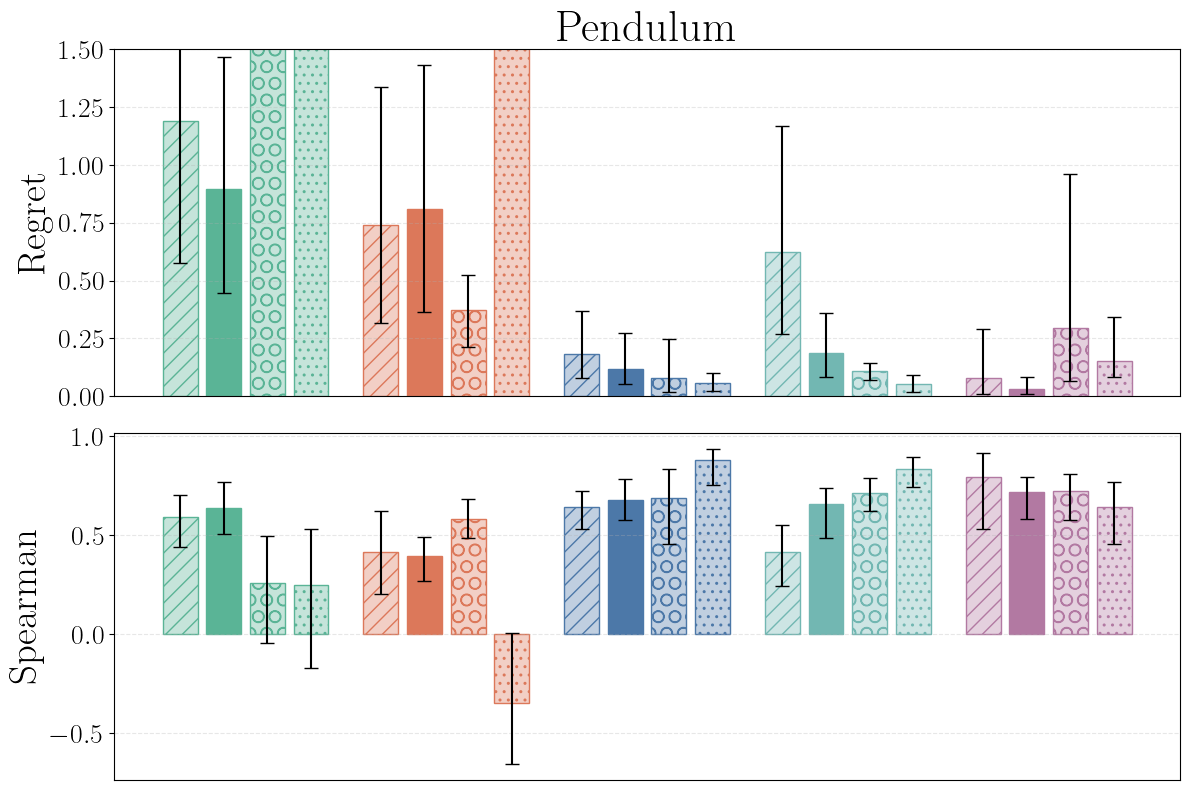

In [ ]:
plot_benchmarks_all(pipeline = 'pendulum_pipeline', seeds = list(range(0,10)), ylim = 1.5, save = True, show_x_labels=False, plot_legend=False)

Processing transformer main seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing transformer ablation seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru main seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing gru ablation seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp main seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing mlp ablation seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet main seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing resnet ablation seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode main seeds [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
Processing ode ablation seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


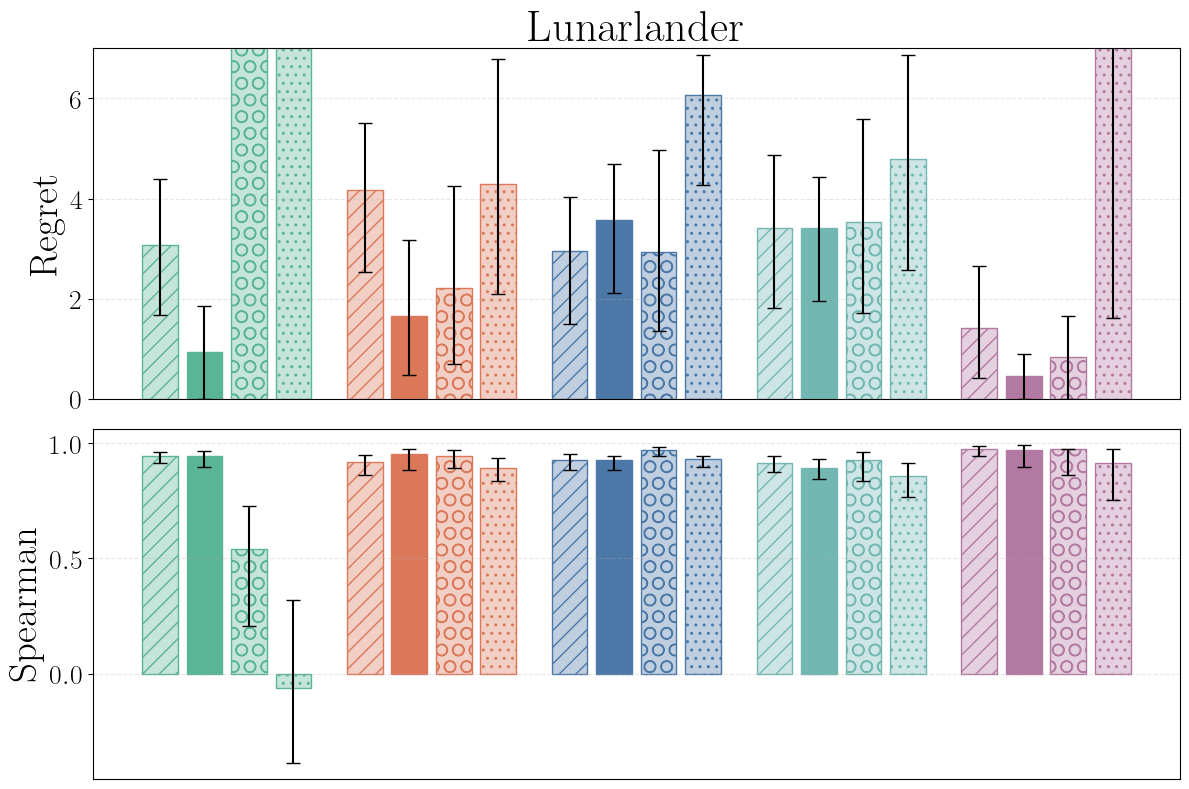

In [111]:
plot_benchmarks_all(pipeline = 'lunarlander_pipeline', seeds = list(range(10,20)), seeds_cr = list(range(0,10)), ylim = 7, save = True, show_x_labels=False)

Processing transformer seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing gru seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing mlp seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing resnet seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...
Processing ode seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]...


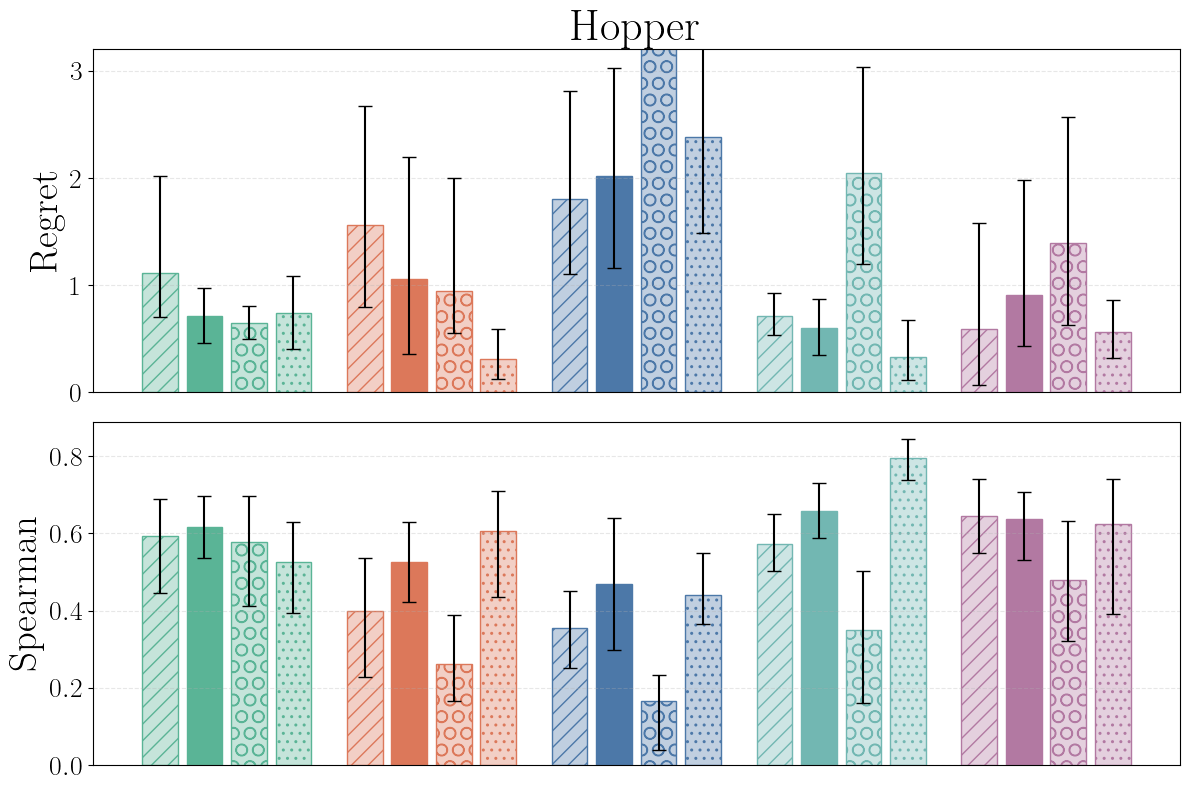

In [69]:
plot_benchmarks_all(pipeline = 'hopper_pipeline', seeds = list(range(2,12)), ylim = 3.2, save = True, show_x_labels=False)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


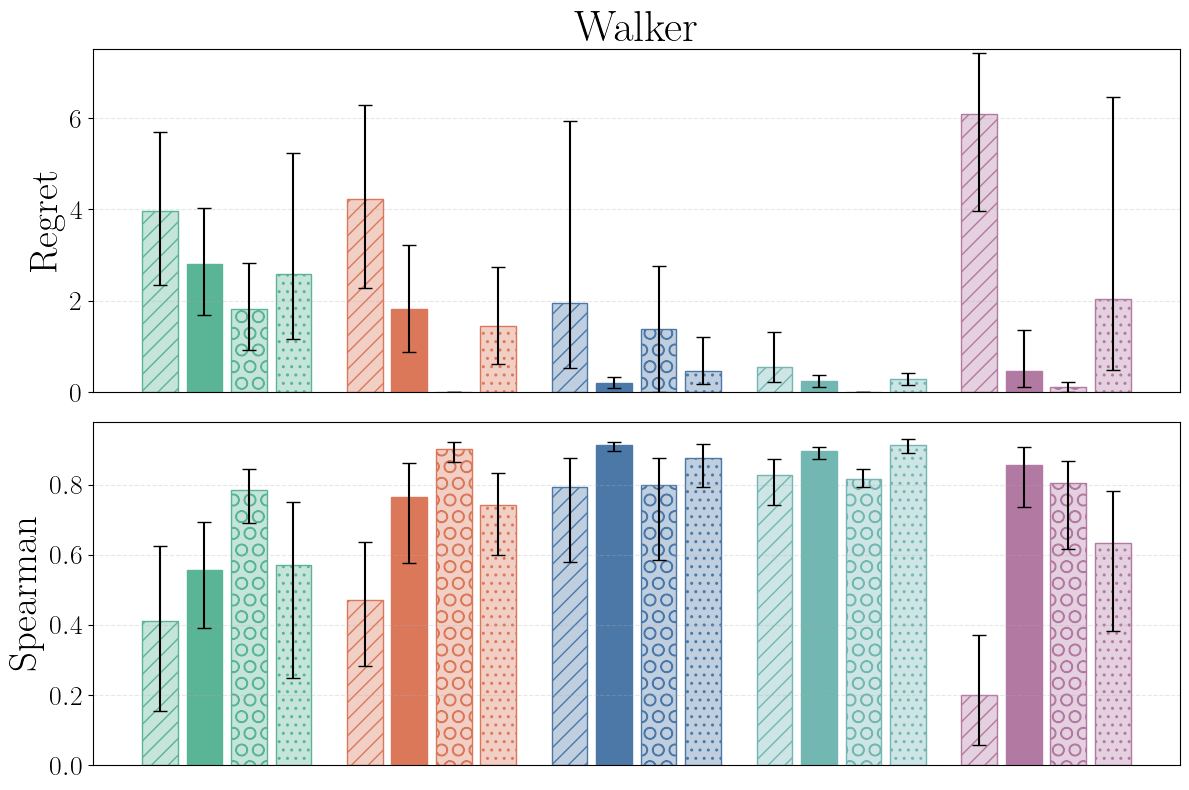

In [70]:
plot_benchmarks_all(pipeline = 'walker_pipeline', seeds = list(range(0,30)), ylim = 7.5, save = True, show_x_labels=False)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


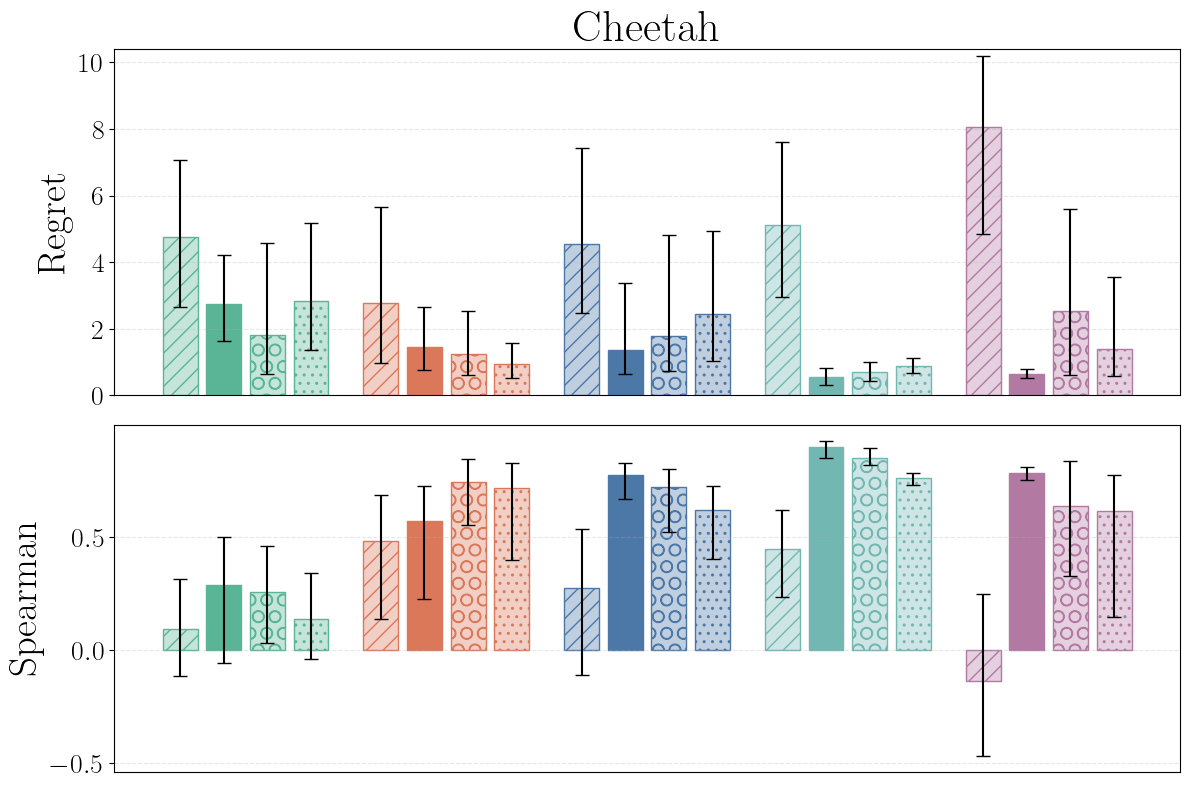

In [71]:
plot_benchmarks_all(pipeline = 'cheetah_pipeline', seeds = list(range(0, 30)), ylim = 10.4, save = True, show_x_labels=False)

Processing transformer seeds [0, 1, 2, 3, 4]...
Processing gru seeds [0, 1, 2, 3, 4]...
Processing mlp seeds [0, 1, 2, 3, 4]...
Processing resnet seeds [0, 1, 2, 3, 4]...
Processing ode seeds [0, 1, 2, 3, 4]...


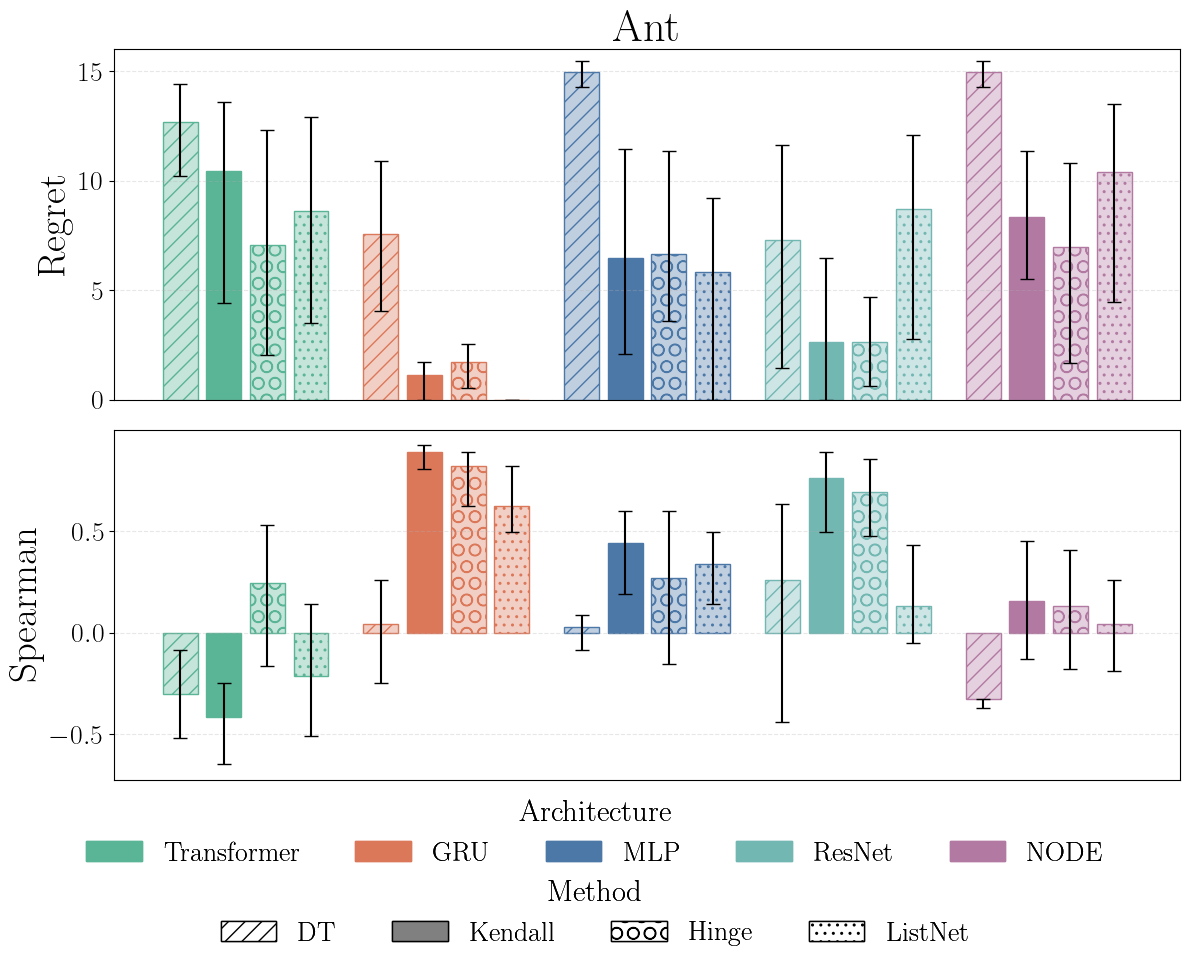

In [76]:
plot_benchmarks_all(pipeline = 'ant_pipeline', seeds = list(range(0, 5)), ylim = 16, save = True, show_x_labels=False, plot_legend=True) #lambda 0.99, rollout len 50

# Cancer OOD results

In [17]:
sup_spearman = [0.35, 0.32, 0.43, 0.62, 0.24, 0.22, 0.44, 0.34, 0.48, 0.53]
kendall_spearman = [0.42, 0.39, 0.49, 0.57, 0.7, 0.61, 0.44, 0.15, 0.34, 0.85]

sup_regret = [134.1, 134.1, 133.8, 0, 133.0, 133.3, 133.4, 133.3, 11.9, 11.9]
kendall_regret = [28.0, 22.7, 22.4, 0, 0, 11.9, 133.4, 133.3, 133.4, 7.6]

In [18]:
mean_se(sup_spearman)

(0.39699999999999996, 0.038027621540138425)

In [19]:
mean_se(kendall_spearman)

(0.496, 0.05913036445008604)

In [20]:
mean_se(sup_regret)

(95.88, 18.232903224665016)

In [21]:
mean_se(kendall_regret)

(49.27, 17.63096735859947)